# Interaction of a Degenerate Qubit with a Many-Body System

In [1]:
# Import libraries
from quspin.operators import hamiltonian, quantum_operator, quantum_LinearOperator, ishamiltonian
from quspin.basis import spin_basis_1d, tensor_basis
from quspin.tools.measurements import ent_entropy, diag_ensemble, obs_vs_time
from quspin.tools.misc import mean_level_spacing

from joblib import Parallel, delayed
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, trapezoid
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde
from tqdm import tqdm

from core import *

# Set default plot parameters
plt.rcParams["font.size"] = 18
plt.rcParams["font.family"] = "Arial"
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"

# Set random seed for reproducibility
rng = np.random.default_rng(42)

## Degenerate System

In [79]:
# System parameters
L = 14  # Number of sites
hx = 1.3  # X field strength
hz = 0.3  # Z field strength
K = 0.5  # Qubit-bath coupling strength

ha = HamiltonianAnalyzer(L, basis_type="spin", pauli=True)

# Nearest-neighbor Ising interaction (periodic BC) in bath (1,..,L-1) with tilted magnetic field
ha.add_static_term(coeff=1., op_str="zz", sites=[[i, i + 1] for i in range(1, L - 1)] + [[L - 1, 1]])
ha.add_static_term(coeff=hx, op_str="x", sites=[[i] for i in range(1, L)])
ha.add_static_term(coeff=hz, op_str="z", sites=[[i] for i in range(1, L)])

# Heisenberg interaction in the qubit (0) with the bath (1,..,L-1)
ha.add_static_term(coeff=K, op_str="heis", sites=[[0, i] for i in range(1, L)])

# Construct the Hamiltonian
H = ha.construct_hamiltonian()

# Perform exact diagonalization
eigvals, eigvecs = ha.diagonalize(H, timeit=True)

Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 2097.1720 seconds.


In [2]:
# Simulate time evolution of the qubit (0) initially in the |0> state and the bath (1,..,L-1) in a Haar-random state
def simulate_time_evolution(ha, eigvals, eigvecs, times, qubit_state=[1, 0], seed=None):
    """
    Simulates the time evolution of the qubit (0) and the bath (1,..,L-1) under the Hamiltonian H.

    Parameters:
    - ha: HamiltonianAnalyzer object containing the Hamiltonian.
    - eigvals: Eigenvalues of the Hamiltonian.
    - eigvecs: Eigenvectors of the Hamiltonian.
    - times: List of time points for evolution.
    - qubit_state: Initial state of the qubit (default is [1, 0] for |0>).
    - seed: Random seed for reproducibility (default is None).

    Returns:
    - obs_time: Observables as a function of time.
    """
    # Initial state: qubit in specified state and bath in Haar-random state
    psi0 = StateGenerator().create_qubit_tensor_haar_state(
        ha.L, 0, qubit_state, seed=seed)

    # Evolve the initial state
    obs_time = ha.compute_time_evolution(psi0, times, eigvals, eigvecs)

    return obs_time

In [ ]:
# Compute time evolution in parallel
realizations = 10 ** 4
times = [100]  # Single time point for long-time evolution

# Run for initial qubit state |0>
obs_time_0 = Parallel(n_jobs=4, verbose=10)(
    delayed(simulate_time_evolution)(
        ha=ha, eigvals=eigvals, eigvecs=eigvecs, times=times, qubit_state=[1, 0], seed=i
    ) for i in range(realizations)
)

# Run for initial qubit state |1>
obs_time_1 = Parallel(n_jobs=4, verbose=10)(
    delayed(simulate_time_evolution)(
        ha=ha, eigvals=eigvals, eigvecs=eigvecs, times=times, qubit_state=[0, 1], seed=i
    ) for i in range(realizations)
)

# Another variant which uses a for loop
# obs_time_0, obs_time_1 = [], []
# for i in tqdm(range(realizations), desc="Simulating time evolution"):
#     obs_time_0.append(
#         simulate_time_evolution(ha, eigvals, eigvecs, times, qubit_state=[1, 0], seed=i)
#     )
#     obs_time_1.append(
#         simulate_time_evolution(ha, eigvals, eigvecs, times, qubit_state=[0, 1], seed=i)
#     )

In [391]:
# Helper function to extract X0, Y0, Z0 from obs_time list
def extract_xyz(obs_time):
    X = np.array([obs["X0"][0] for obs in obs_time])
    Y = np.array([obs["Y0"][0] for obs in obs_time])
    Z = np.array([obs["Z0"][0] for obs in obs_time])
    return X, Y, Z

# Helper function to convert Cartesian to spherical coordinates
def cartesian_to_spherical(x, y, z):
    r = np.sqrt(x ** 2 + y ** 2 + z ** 2)
    u = z / r
    phi = np.arctan2(y, x)
    return r, u, phi

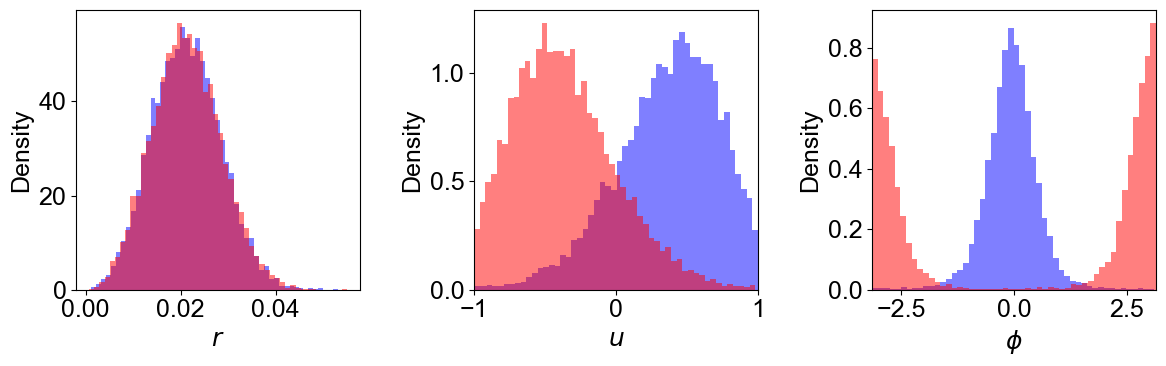

In [ ]:
# Extract for |0> and |1> initial states
X0_0, Y0_0, Z0_0 = extract_xyz(obs_time_0)
X0_1, Y0_1, Z0_1 = extract_xyz(obs_time_1)

# Spherical coordinates for |0> and |1> initial states
r0, u0, phi0 = cartesian_to_spherical(X0_0, Y0_0, Z0_0)
r1, u1, phi1 = cartesian_to_spherical(X0_1, Y0_1, Z0_1)

# Plot histograms of r, u, phi for both initial states
fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=100)

hist_r_0, bins_r_0, _ = axs[0].hist(r0, bins=50, density=True, alpha=0.5, color="blue")
hist_r_1, bins_r_1, _ = axs[0].hist(r1, bins=50, density=True, alpha=0.5, color="red")
axs[0].set_xlabel(r"$r$")
axs[0].set_ylabel("Density")

hist_u_0, bins_u_0, _ = axs[1].hist(u0, bins=50, density=True, alpha=0.5, color="blue")
hist_u_1, bins_u_1, _ = axs[1].hist(u1, bins=50, density=True, alpha=0.5, color="red")
axs[1].set_xlim(-1, 1)
axs[1].set_xlabel(r"$u$")
axs[1].set_ylabel("Density")

hist_phi_0, bins_phi_0, _ = axs[2].hist(phi0, bins=50, density=True, alpha=0.5, color="blue")
hist_phi_1, bins_phi_1, _ = axs[2].hist(phi1, bins=50, density=True, alpha=0.5, color="red")
axs[2].set_xlim(-np.pi, np.pi)
axs[2].set_xlabel(r"$\phi$")
axs[2].set_ylabel("Density")

plt.tight_layout()
plt.show()

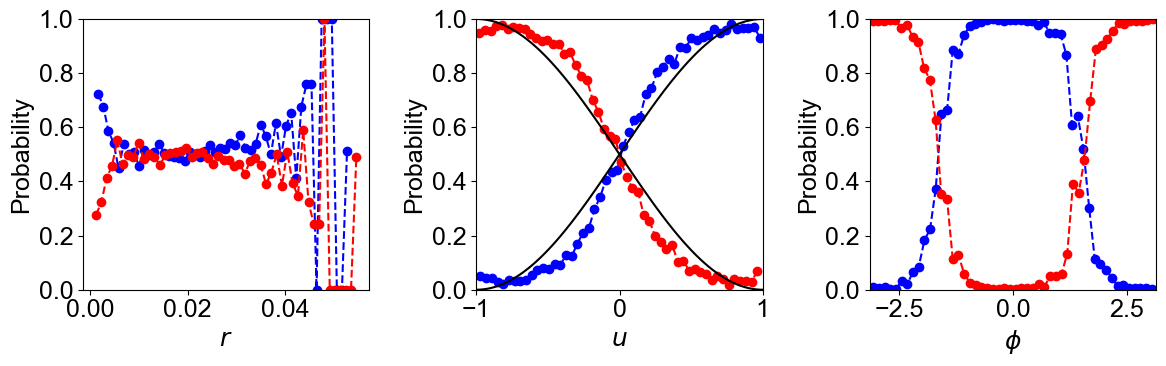

In [83]:
# Compute posterior distributions by dividing each histogram by their sum
x_r_0 = 0.5 * (bins_r_0[:-1] + bins_r_0[1:])
x_r_1 = 0.5 * (bins_r_1[:-1] + bins_r_1[1:])
x_u_0 = 0.5 * (bins_u_0[:-1] + bins_u_0[1:])
x_u_1 = 0.5 * (bins_u_1[:-1] + bins_u_1[1:])
x_phi_0 = 0.5 * (bins_phi_0[:-1] + bins_phi_0[1:])
x_phi_1 = 0.5 * (bins_phi_1[:-1] + bins_phi_1[1:])

eps = 1e-12  # Small value to avoid division by zero

p_r_0 = hist_r_0 / (hist_r_0 + hist_r_1 + eps)
p_r_1 = hist_r_1 / (hist_r_0 + hist_r_1 + eps)
p_u_0 = hist_u_0 / (hist_u_0 + hist_u_1 + eps)
p_u_1 = hist_u_1 / (hist_u_0 + hist_u_1 + eps)
p_phi_0 = hist_phi_0 / (hist_phi_0 + hist_phi_1 + eps)
p_phi_1 = hist_phi_1 / (hist_phi_0 + hist_phi_1 + eps)

fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=100)

axs[0].plot(x_r_0, p_r_0, linestyle="--", marker="o", color="blue")
axs[0].plot(x_r_1, p_r_1, linestyle="--", marker="o", color="red")
axs[0].set_ylim(0, 1)
axs[0].set_xlabel(r"$r$")
axs[0].set_ylabel("Probability")

axs[1].plot(x_u_0, p_u_0, linestyle="--", marker="o", color="blue")
axs[1].plot(x_u_1, p_u_1, linestyle="--", marker="o", color="red")
x_u_plt = np.linspace(-1, 1, 100)
axs[1].plot(x_u_plt, np.cos(np.pi / 4 * (x_u_plt + 1)) ** 2, color="black")
axs[1].plot(x_u_plt, np.sin(np.pi / 4 * (x_u_plt + 1)) ** 2, color="black")
axs[1].set_ylim(0, 1)
axs[1].set_xlim(-1, 1)
axs[1].set_xlabel(r"$u$")
axs[1].set_ylabel("Probability")

axs[2].plot(x_phi_0, p_phi_0, linestyle="--", marker="o", color="blue")
axs[2].plot(x_phi_1, p_phi_1, linestyle="--", marker="o", color="red")
axs[2].set_ylim(0, 1)
axs[2].set_xlim(-np.pi, np.pi)
axs[2].set_xlabel(r"$\phi$")
axs[2].set_ylabel("Probability")

plt.tight_layout()
plt.show()


## Non-Degenerate System

In [24]:
L = 5  # Number of sites
w0 = 10.  # Qubit frequency
hx = 1.3  # X field strength
hz = 0.3  # Z field strength
K = 0.5  # Qubit-bath coupling strength

# Create degenerate Hamiltonian
hd = HamiltonianAnalyzer(L, basis_type="spin", pauli=True)
hd.add_static_term(coeff=1., op_str="zz", sites=[[i, i + 1] for i in range(1, L - 1)] + [[L - 1, 1]])
hd.add_static_term(coeff=hx, op_str="x", sites=[[i] for i in range(1, L)])
hd.add_static_term(coeff=hz, op_str="z", sites=[[i] for i in range(1, L)])
hd.add_static_term(coeff=K, op_str="heis", sites=[[0, i] for i in range(1, L)])
Hd = hd.construct_hamiltonian()

#nCreate non-degenerate Hamiltonian
hn = HamiltonianAnalyzer(L, basis_type="spin", pauli=True)
hn.add_static_term(coeff=1., op_str="zz", sites=[[i, i + 1] for i in range(1, L - 1)] + [[L - 1, 1]])
hn.add_static_term(coeff=hx, op_str="x", sites=[[i] for i in range(1, L)])
hn.add_static_term(coeff=hz, op_str="z", sites=[[i] for i in range(1, L)])
hn.add_static_term(coeff=K, op_str="heis", sites=[[0, i] for i in range(1, L)])
hn.add_static_term(coeff=w0, op_str="z", sites=[[0]])
Hn = hn.construct_hamiltonian()

# Perform exact diagonalization
Ed, Vd = hd.diagonalize(Hd, timeit=True)
En, Vn = hn.diagonalize(Hn, timeit=True)

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 0.0055 seconds.
Diagonalization took 0.0000 seconds.


In [25]:
# Compute time evolution in parallel
realizations = 10 ** 4
times = [100]  # Single time point for long-time evolution

# Run for initial qubit state in a weighted superposition of |0> and |1>, with and without degeneracy
psi0 = [np.sqrt(0.9), np.sqrt(0.1)]

obs_time_d = Parallel(n_jobs=4, verbose=10)(
    delayed(simulate_time_evolution)(
        ha=hd, eigvals=Ed, eigvecs=Vd, times=times, qubit_state=psi0, seed=i
    ) for i in range(realizations)
)
obs_time_n = Parallel(n_jobs=4, verbose=10)(
    delayed(simulate_time_evolution)(
        ha=hn, eigvals=En, eigvecs=Vn, times=times, qubit_state=psi0, seed=i
    ) for i in range(realizations)
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Batch computation too fast (0.009993314743041992s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Batch computation too fast (0.014435529708862305s.) Setting batch_size=4.
[Parallel(n_jobs=4)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Batch computation too fast (0.01840043067932129s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Done  56 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Batch computation too fast (0.02010512351989746s.) Setting batch_size=16.
[Parallel(n_jobs=4)]: Done 136 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Batch computation too fast (0.033544301986694336s.) Setting batch_size=32.
[Parallel(n_jobs=4)]: Batch computation too fast (0.0511782169342041s.) Setting batch_size=64.
[Parallel(n_jobs=4)]: Done 312 tasks      | e

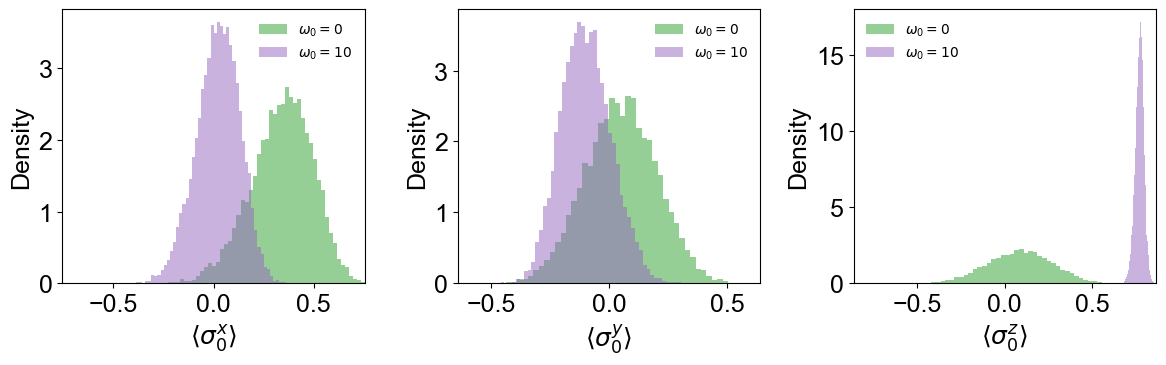

In [26]:
# Plot histograms of r, u=cos(theta), phi for degenerate and non-degenerate cases
X0_d, Y0_d, Z0_d = extract_xyz(obs_time_d)
X0_n, Y0_n, Z0_n = extract_xyz(obs_time_n)

r_d, u_d, phi_d = cartesian_to_spherical(X0_d, Y0_d, Z0_d)
r_n, u_n, phi_n = cartesian_to_spherical(X0_n, Y0_n, Z0_n)

fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=100)

axs[0].hist(X0_d, bins=50, density=True, alpha=0.5, color="C2", label=r"$\omega_0=0$")
axs[0].hist(X0_n, bins=50, density=True, alpha=0.5, color="C4", label=r"$\omega_0=10$")
bnd = np.maximum(np.abs(X0_d).max(), np.abs(X0_n).max())
axs[0].set_xlim(-bnd, bnd)
axs[0].set_xlabel(r"$\langle\sigma_0^x\rangle$")
axs[0].set_ylabel("Density")
axs[0].legend(fontsize=10, frameon=False)

axs[1].hist(Y0_d, bins=50, density=True, alpha=0.5, color="C2", label=r"$\omega_0=0$")
axs[1].hist(Y0_n, bins=50, density=True, alpha=0.5, color="C4", label=r"$\omega_0=10$")
bnd = np.maximum(np.abs(Y0_d).max(), np.abs(Y0_n).max())
axs[1].set_xlim(-bnd, bnd)
axs[1].set_xlabel(r"$\langle\sigma_0^y\rangle$")
axs[1].set_ylabel("Density")
axs[1].legend(fontsize=10, frameon=False)

axs[2].hist(Z0_d, bins=50, density=True, alpha=0.5, color="C2", label=r"$\omega_0=0$")
axs[2].hist(Z0_n, bins=50, density=True, alpha=0.5, color="C4", label=r"$\omega_0=10$")
bnd = np.maximum(np.abs(Z0_d).max(), np.abs(Z0_n).max())
axs[2].set_xlim(-bnd, bnd)
axs[2].set_xlabel(r"$\langle\sigma_0^z\rangle$")
axs[2].set_ylabel("Density")
axs[2].legend(fontsize=10, frameon=False)

plt.tight_layout()
plt.show()

## Multiple Static Frequencies

In [2]:
def simulate_time_evolution(ha, eigvals, eigvecs, times, qubit_state=[1, 0], bath_state=None, seed=None):
    """
    Simulates the time evolution of the qubit (0) and the bath (1,..,L-1) under the Hamiltonian H.

    Parameters:
    - ha: HamiltonianAnalyzer object containing the Hamiltonian.
    - eigvals: Eigenvalues of the Hamiltonian.
    - eigvecs: Eigenvectors of the Hamiltonian.
    - times: List of time points for evolution.
    - qubit_state: Initial state of the qubit (default is [1, 0] for |0>).
    - bath_state: State vector for the bath (default is None, uses Haar-random state).
    - seed: Random seed for reproducibility (default is None).

    Returns:
    - obs_time: Observables as a function of time.
    """
    sg = StateGenerator()
    if bath_state is None:
        psi0 = sg.create_qubit_tensor_haar_state(
            ha.L, 0, qubit_state, seed=seed)
    else:
        # Tensor product of qubit_state and bath_state
        psi0 = sg.create_tensor_product_state(
            np.array(qubit_state, dtype=np.complex128), bath_state)

    obs_time = ha.compute_time_evolution(psi0, times, eigvals, eigvecs)
    return obs_time

In [5]:
# Repeat for multiple static frequencies and number of sites
Ls = [5, 6, 7, 8, 9, 10, 11, 12, 13]  # Number of sites
w0s = [0, 0.1, 0.2, 0.5, 1., 2., 5., 10., 20., 50., 100.]  # Static frequencies
hx = 1.3  # X field strength
hz = 0.3  # Z field strength
g = 1.  # Qubit-bath coupling strength

res = []
for L in tqdm(Ls, desc="Number of sites"):
    # Diagonalize only bath portion of the Hamiltonian
    ha = HamiltonianAnalyzer(L - 1, basis_type="spin", pauli=True)
    ha.add_static_term(coeff=1., op_str="zz", sites=[
        [i, i + 1] for i in range(0, L - 2)] + [[L - 2, 0]])
    ha.add_static_term(coeff=hx, op_str="x", sites=[
        [i] for i in range(0, L - 1)])
    ha.add_static_term(coeff=hz, op_str="z", sites=[
        [i] for i in range(0, L - 1)])
    Hb = ha.construct_hamiltonian()

    Eb, Vb = ha.diagonalize(Hb, timeit=True)

    for w0 in w0s:
        # Construct Hamiltonian
        ha = HamiltonianAnalyzer(L, basis_type="spin", pauli=True)
        ha.add_static_term(coeff=1., op_str="zz", sites=[
                           [i, i + 1] for i in range(1, L - 1)] + [[L - 1, 1]])
        ha.add_static_term(coeff=hx, op_str="x", sites=[
                           [i] for i in range(1, L)])
        ha.add_static_term(coeff=hz, op_str="z", sites=[
                           [i] for i in range(1, L)])
        ha.add_static_term(coeff=g, op_str="heis", sites=[
                           [0, i] for i in range(1, L)])

        # Static frequency for qubit
        ha.add_static_term(coeff=w0 / 2, op_str="z", sites=[[0]])
        H = ha.construct_hamiltonian()

        # Perform exact diagonalization
        E, V = ha.diagonalize(H, timeit=True)

        # Compute time evolution in parallel
        times = [100]  # Single time point for long-time evolution

        # Run for initial qubit state in a weighted superposition of |0> and |1>
        psi0 = [np.sqrt(0.9), np.sqrt(0.1)]

        # Iterate over all eigenstates as initial bath states
        obs_time = Parallel(n_jobs=4, verbose=1)(
            delayed(simulate_time_evolution)(
                ha=ha, eigvals=E, eigvecs=V, times=times, qubit_state=psi0, bath_state=Vb[:, i]
            ) for i in range(Vb.shape[1])
        )

        # Extract observables
        X0, Y0, Z0 = extract_xyz(obs_time)

        # Append results
        res.append({
            "L": L,
            "w0": w0,
            "X0": X0,
            "Y0": Y0,
            "Z0": Z0
        })

Number of sites:   0%|          | 0/9 [00:00<?, ?it/s]

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  16 out of  16 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  16 out of  16 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  16 out of  16 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  16 out of  16 | elapsed:    0.0s finished


Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 0.0010 seconds.
Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 0.0000 seconds.
Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 0.0010 seconds.
Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 0.0000 seconds.
Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 0.0000 seconds.
Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 0.0000 seconds.


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  16 out of  16 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  16 out of  16 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  16 out of  16 | elapsed:    0.0s finished


Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 0.0000 seconds.
Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 0.0040 seconds.
Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 0.0000 seconds.


...

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   32.5s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:  2.4min
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:  5.3min
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:  9.3min
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed: 14.4min
[Parallel(n_jobs=4)]: Done 1792 tasks      | elapsed: 20.5min
[Parallel(n_jobs=4)]: Done 2442 tasks      | elapsed: 27.7min
[Parallel(n_jobs=4)]: Done 3192 tasks      | elapsed: 35.9min
[Parallel(n_jobs=4)]: Done 4042 tasks      | elapsed: 45.2min
[Parallel(n_jobs=4)]: Done 4096 out of 4096 | elapsed: 45.8min finished


Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 158.3076 seconds.


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   32.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:  2.3min
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:  5.2min
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:  9.1min
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed: 14.1min
[Parallel(n_jobs=4)]: Done 1792 tasks      | elapsed: 20.6min
[Parallel(n_jobs=4)]: Done 2442 tasks      | elapsed: 27.8min
[Parallel(n_jobs=4)]: Done 3192 tasks      | elapsed: 36.0min
[Parallel(n_jobs=4)]: Done 4042 tasks      | elapsed: 45.4min
[Parallel(n_jobs=4)]: Done 4096 out of 4096 | elapsed: 46.0min finished


Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 157.7948 seconds.


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   32.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:  2.2min
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:  5.0min
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:  8.9min
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed: 13.9min
[Parallel(n_jobs=4)]: Done 1792 tasks      | elapsed: 21.0min
[Parallel(n_jobs=4)]: Done 2442 tasks      | elapsed: 28.8min
[Parallel(n_jobs=4)]: Done 3192 tasks      | elapsed: 37.3min
[Parallel(n_jobs=4)]: Done 4042 tasks      | elapsed: 46.6min
[Parallel(n_jobs=4)]: Done 4096 out of 4096 | elapsed: 47.2min finished
Number of sites: 100%|██████████| 9/9 [10:47:33<00:00, 4317.10s/it] 


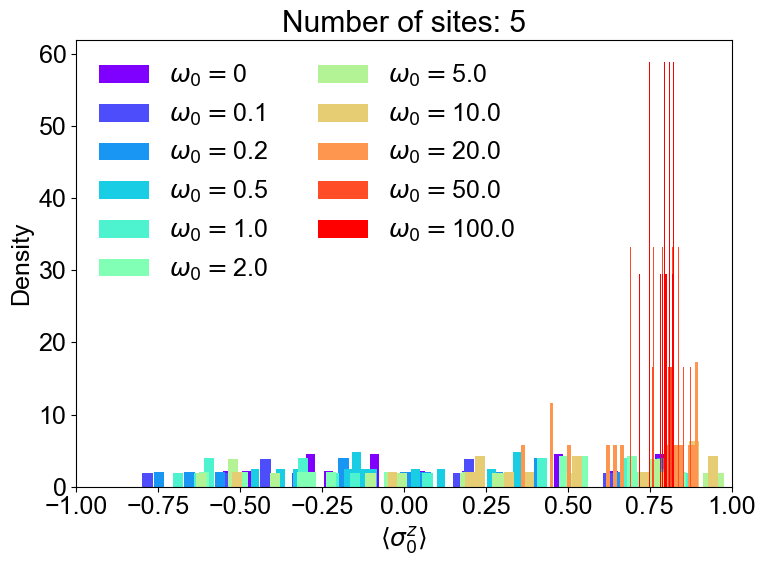

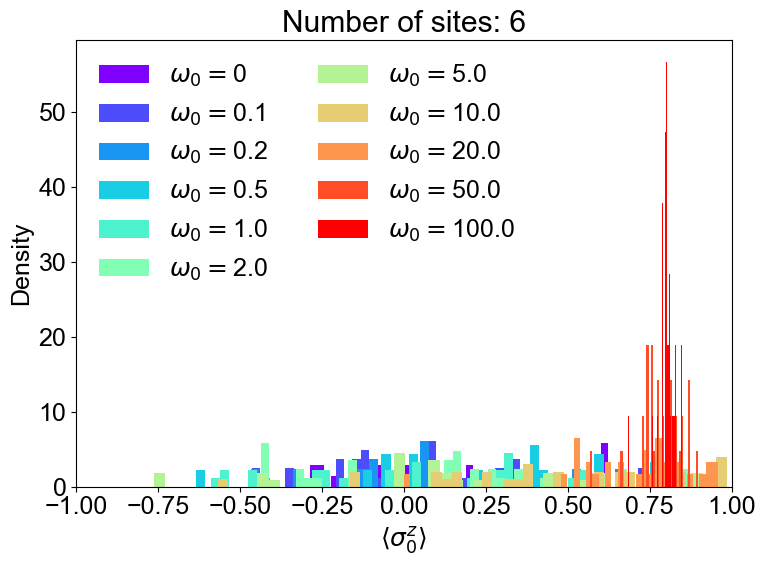

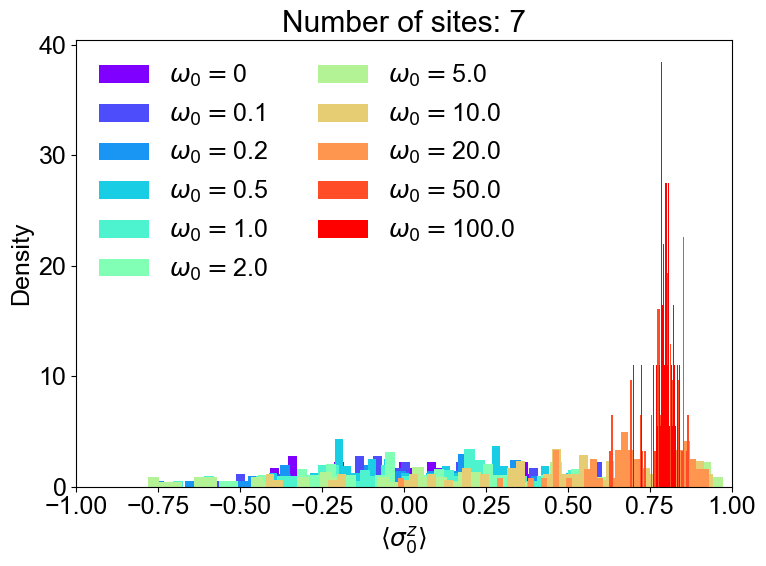

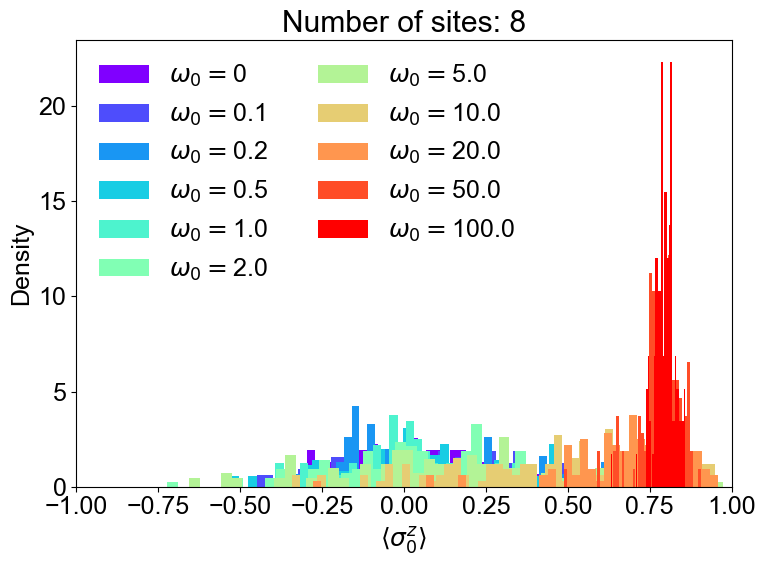

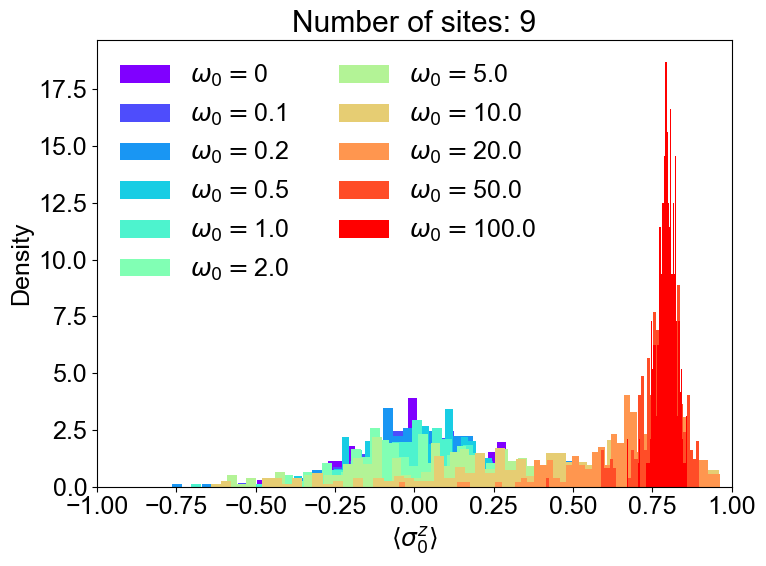

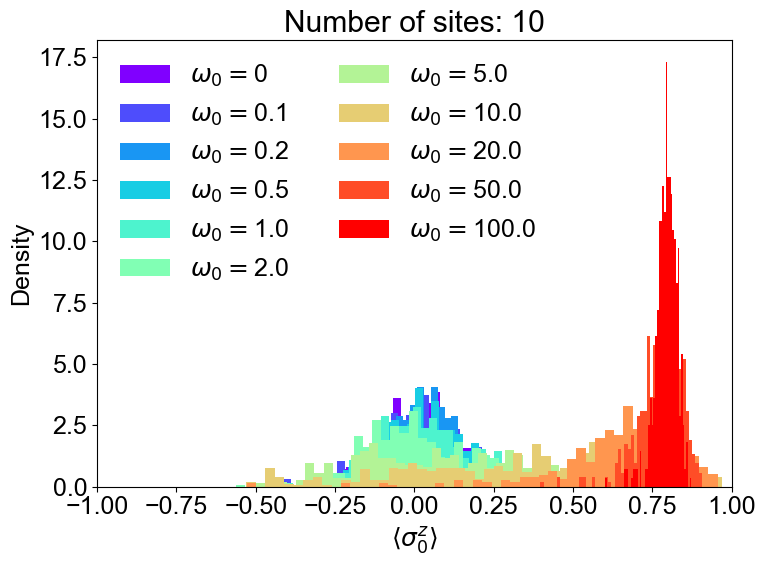

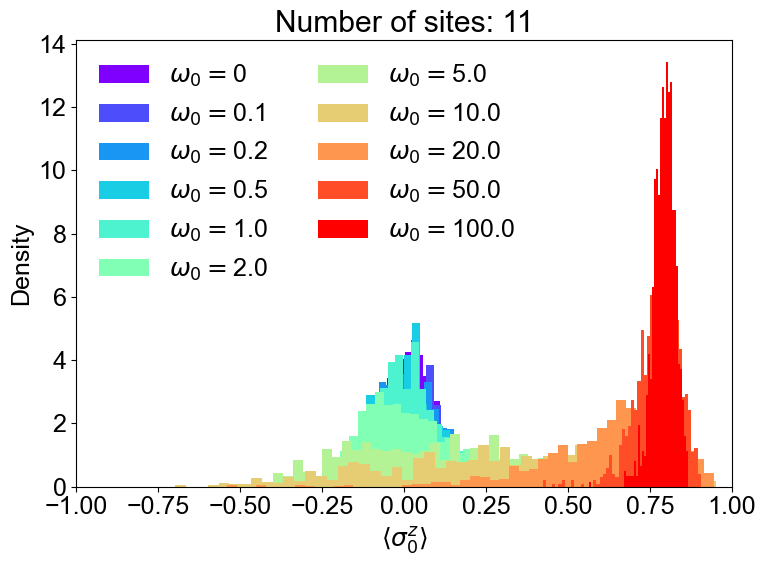

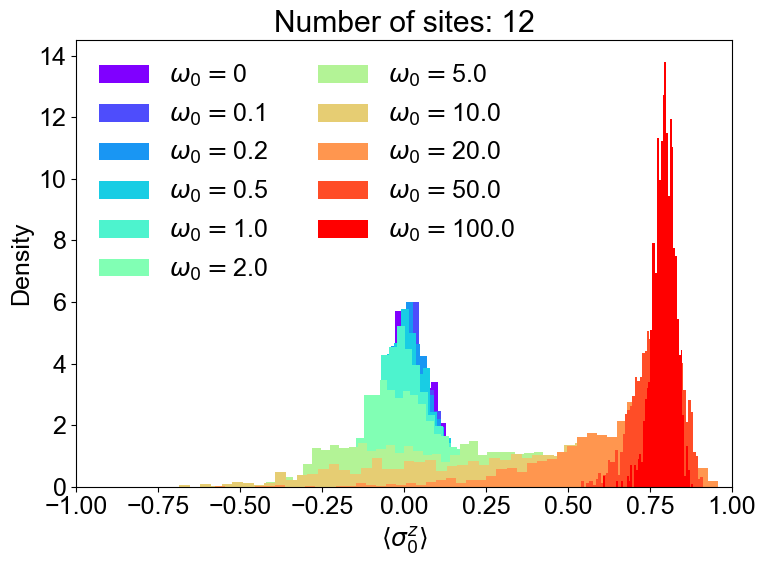

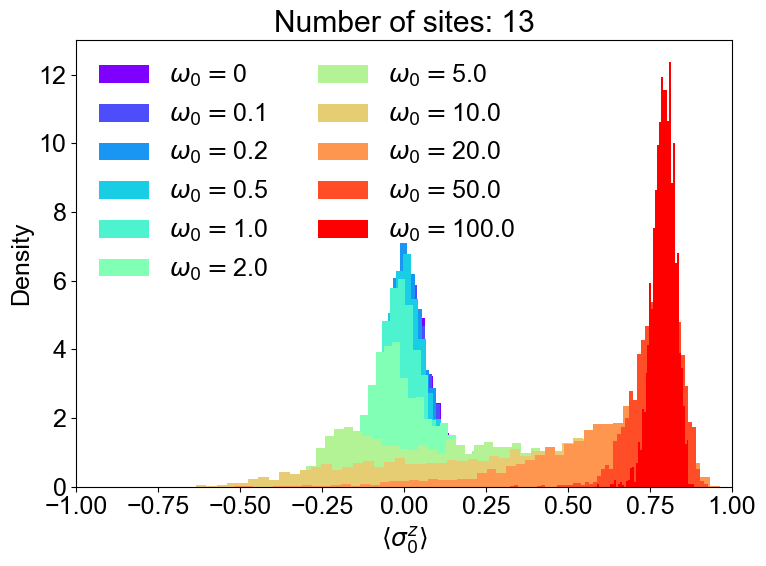

In [6]:
# Plot histograms for each L
cmap = plt.get_cmap("rainbow")

for L in Ls:
    data = [r for r in res if r["L"] == L]

    fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)

    for idx, d in enumerate(data):
        ax.hist(d["Z0"], bins=50, density=True, label=f"$\omega_0=${d['w0']}", color=cmap(idx / (len(data) - 1)))

    ax.set_xlabel(r"$\langle\sigma_0^z\rangle$")
    ax.set_ylabel("Density")

    ax.legend(ncol=2, frameon=False)
    ax.set_xlim(-1, 1)

    ax.set_title(f"Number of sites: {L}")
    
    plt.tight_layout()
    plt.show()

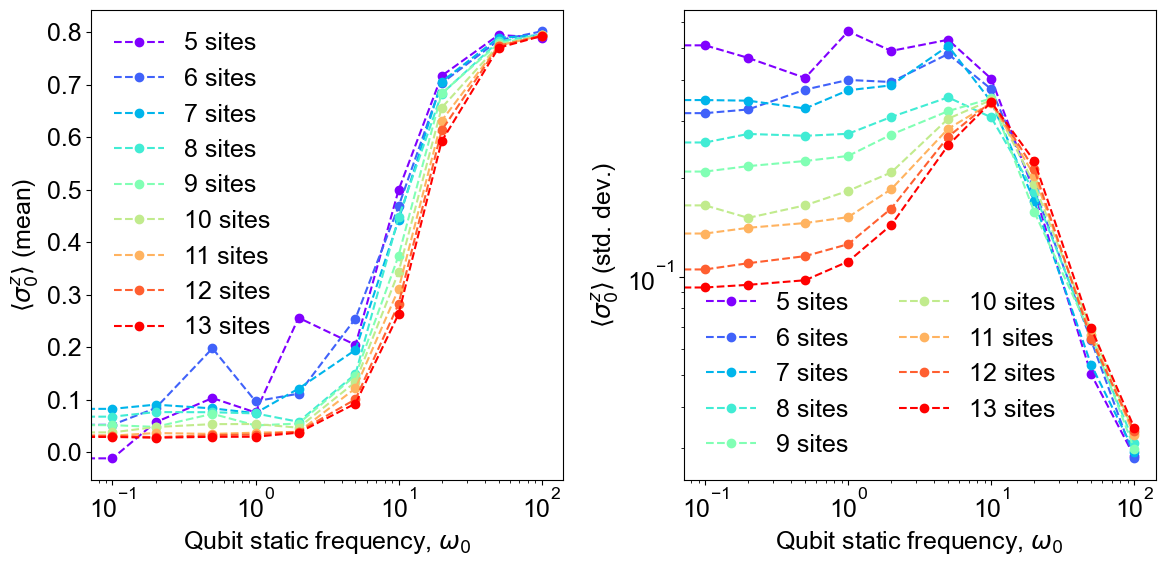

In [9]:
# Plot mean and std. dev of Z0 as a function of w0 for each L
cmap = plt.get_cmap("rainbow")
fig, axs = plt.subplots(1, 2, figsize=(12, 6), dpi=100)
for idx, L in enumerate(Ls):
    mean_Z0 = [np.mean([r["Z0"] for r in res if r["w0"] == w0 and r["L"] == L][0]) for w0 in w0s]
    std_Z0 = [np.std([r["Z0"] for r in res if r["w0"] == w0 and r["L"] == L][0]) for w0 in w0s]
    axs[0].plot(w0s, mean_Z0, marker="o", linestyle="--", label=f"{L} sites", color=cmap(idx / (len(Ls) - 1)))
    axs[1].plot(w0s, std_Z0, marker="o", linestyle="--", label=f"{L} sites", color=cmap(idx / (len(Ls) - 1)))
for ax in axs:
    ax.set_xscale("log")
    ax.set_xlabel("Qubit static frequency, $\omega_0$")
axs[0].legend(frameon=False)
axs[1].legend(ncol=2, frameon=False)
axs[1].set_yscale("log")
axs[0].set_ylabel(r"$\langle\sigma_0^z\rangle$ (mean)")
axs[1].set_ylabel(r"$\langle\sigma_0^z\rangle$ (std. dev.)")
plt.tight_layout()
plt.show()

## Lindblad rate coefficients

In [2]:
def construct_bath_hamiltonian_analyzer(L, hx, hz, h1, hL):
    """
    Constructs the HamiltonianAnalyzer for the bath with open boundary conditions and inversion symmetry breaking.

    Parameters:
        L (int): Number of sites in the bath.
        hx (float): X field strength.
        hz (float): Z field strength.
        h1 (float): Z field strength at the first site (site 0).
        hL (float): Z field strength at the last site (site L-1).

    Returns:
        HamiltonianAnalyzer: Analyzer object for the bath Hamiltonian.
    """
    ha = HamiltonianAnalyzer(L, basis_type="spin", pauli=True)
    ha.add_static_term(coeff=1., op_str="zz", sites=[[i, i + 1] for i in range(0, L - 1)])
    ha.add_static_term(coeff=hx, op_str="x", sites=[[i] for i in range(0, L)])
    ha.add_static_term(coeff=hz, op_str="z", sites=[[i] for i in range(0, L)])
    ha.add_static_term(coeff=h1, op_str="z", sites=[[0]])
    ha.add_static_term(coeff=hL, op_str="z", sites=[[L - 1]])
    return ha

def construct_total_hamiltonian_analyzer(L, hx, hz, h1, hL, g, w0):
    """
    Constructs the total HamiltonianAnalyzer for the system with a qubit and a bath.

    Parameters:
        L (int): Number of bath sites (not including the qubit).
        hx (float): X field strength for bath.
        hz (float): Z field strength for bath.
        h1 (float): Z field at first bath site.
        hL (float): Z field at last bath site.
        g (float): Qubit-bath coupling strength.
        w0 (float): Qubit frequency.

    Returns:
        HamiltonianAnalyzer: Analyzer object for the total Hamiltonian.
    """
    # Basis for the qubit (site 0) and bath (sites 1..L)
    basis_list = [("spin", 1, True, {}), ("spin", L, True, {})]
    ha = HamiltonianAnalyzer(basis_list=basis_list)

    ha.add_static_term(coeff=1., op_str="|zz", sites=[[i, i + 1] for i in range(L - 1)])
    ha.add_static_term(coeff=hx, op_str="|x", sites=[[i] for i in range(L)])
    ha.add_static_term(coeff=hz, op_str="|z", sites=[[i] for i in range(L)])
    ha.add_static_term(coeff=h1, op_str="|z", sites=[[0]])
    ha.add_static_term(coeff=hL, op_str="|z", sites=[[L - 1]])
    ha.add_static_term(coeff=w0 / 2, op_str="z|", sites=[[0]])
    ha.add_static_term(coeff=g, op_str="x|x", sites=[[0, 0]])
    return ha

In [117]:
def poly_8(x, a, b, c, d, e, f, g, h, i):
    return (a * x**8 + b * x**7 + c * x**6 + d * x**5
            + e * x**4 + f * x**3 + g * x**2 + h * x + i)

def compute_level_spacing_distribution(eigvals, num_bins_staircase=51):
    """
    Computes the unfolded level spacing distribution from a set of eigenvalues.

    Parameters:
    eigvals (np.ndarray): Array of eigenvalues, sorted in ascending order.
    num_bins_staircase (int): Number of bins for estimating the staircase function.

    Returns:
    s (np.ndarray): Array of unfolded level spacings.
    extra (dict): Dictionary containing bins, staircase function, and polynomial fit parameters.
    """
    # First, estimate staircase function (number of eigenvalues below each energy)
    bins_I = np.linspace(eigvals[0], eigvals[-1], num_bins_staircase)
    I = np.array([np.sum(eigvals < b) for b in bins_I[:-1]])

    # Fit 8th-order polynomial to the staircase function
    params, _ = curve_fit(poly_8, bins_I[:-1], I)

    # Compute unfolded eigenvalues using the fitted polynomial
    eps = poly_8(eigvals, *params)

    # Compute level spacings
    s = np.diff(eps)
    s = s[s > 0]  # Keep only positive spacings

    extra = {
        "bins_I": bins_I,
        "I": I,
        "poly_fit_params": params,
    }

    return s, extra

def wigner_surmise(s):
    return (np.pi / 2) * s * np.exp(-np.pi / 4 * s**2)

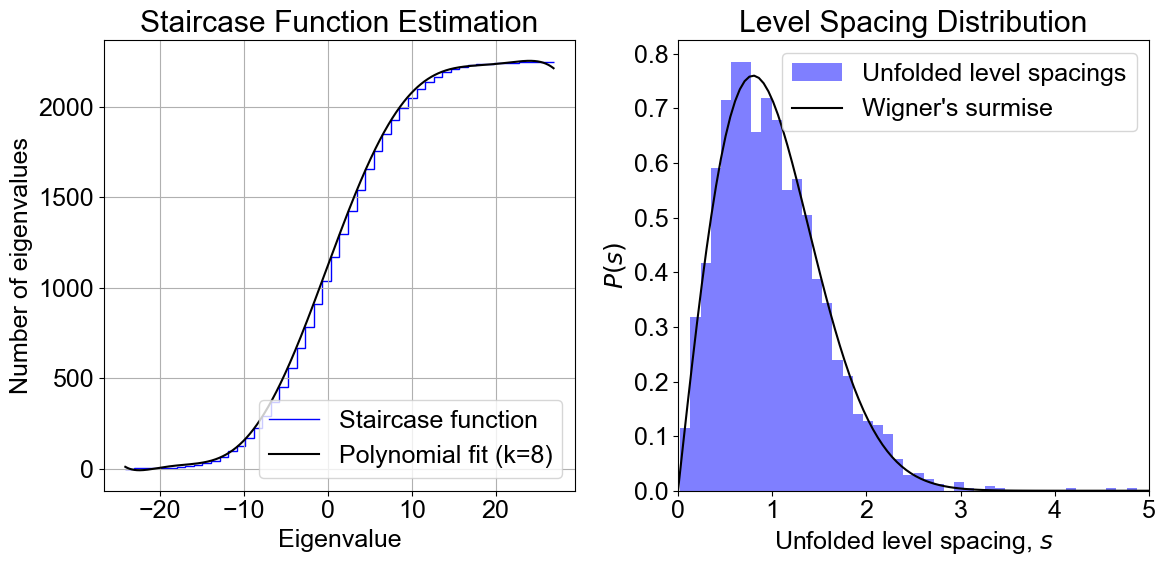

In [155]:
# Compute level spacing distribution
s, extra = compute_level_spacing_distribution(eigvals, num_bins_staircase=51)

fig, axs = plt.subplots(1, 2, figsize=(12, 6), dpi=100)

# Plot staircase function and polynomial fit
E_poly = np.linspace(eigvals[0], eigvals[-1], 1000)
axs[0].stairs(extra["I"], extra["bins_I"], baseline=None, label="Staircase function", color="blue")
axs[0].plot(E_poly, poly_8(E_poly, *extra["poly_fit_params"]), label="Polynomial fit (k=8)", color="k")
axs[0].set_xlabel("Eigenvalue")
axs[0].set_ylabel("Number of eigenvalues")
axs[0].legend()
axs[0].grid()
axs[0].set_title("Staircase Function Estimation")

# Plot level spacing distribution compared to Wigner's surmise
axs[1].hist(s, bins=100, density=True, alpha=0.5, color="blue", label="Unfolded level spacings")
axs[1].plot(np.linspace(0, 5, 100), wigner_surmise(np.linspace(0, 5, 100)), color="k", label="Wigner's surmise")
axs[1].set_xlim(0, 5)
axs[1].set_xlabel("Unfolded level spacing, $s$")
axs[1].set_ylabel("$P(s)$")
axs[1].legend()
axs[1].set_title("Level Spacing Distribution")

plt.tight_layout()
plt.show()

In [3]:
def compute_spectral_density_matrix_elements(eigvals, eigstates, basis, bath_idx=0):
    """
    Computes the matrix elements of the Sx operator on first qubit between a reference bath eigenstate and all other eigenstates of the bath Hamiltonian.

    Parameters:
        eigvals (np.ndarray): Eigenvalues of the bath Hamiltonian.
        eigstates (np.ndarray): Matrix of eigenvectors (columns are eigenstates).
        basis (basis): Basis object for the bath Hamiltonian.
        bath_idx (int): Index of the reference bath eigenstate (default: 0).

    Returns:
        A (np.ndarray): Array of matrix elements |<psi_B|Sx1|psi_E>| ^ 2.
    """
    # Sx operator for the first bath qubit
    Sx1 = quantum_LinearOperator(
        [["x", [[1.0, 0]]]], basis=basis, dtype=np.complex128, check_symm=False, check_herm=False)

    # Compute matrix elements in the bath eigenbasis
    A = []
    psiB = eigstates[:, bath_idx]

    for i in tqdm(range(eigstates.shape[1]), desc="Computing matrix elements"):
        psiE = eigstates[:, i]
        Ai = np.abs(Sx1.matrix_ele(psiB, psiE)) ** 2 if i != bath_idx else 0
        A.append(Ai)

    return np.array(A, dtype=np.complex128)


def compute_spectral_density(w0s, eigvals, A, g, bath_idx=0, sigma=1.0):
    """
    Computes the spectral density from the matrix elements of the Sx1 operator.

    Parameters:
        w0s (np.ndarray): Frequencies for which to compute the spectral density.
        eigvals (np.ndarray): Eigenvalues of the bath Hamiltonian.
        A (np.ndarray): Matrix elements |<psi_B|Sx1|psi_E>| ^ 2.
        g (float): Coupling strength between the qubit and the bath.
        bath_idx (int): Index of the reference bath eigenstate (default: 0).
        sigma (float): Standard deviation of the Gaussian broadening (default: 1.0).

    Returns:
        gamma (np.ndarray): Bath spectral density at frequencies w0s.
    """
    def gaussian(x, mu, sigma):
        return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

    Ebath = eigvals[bath_idx]

    gamma = np.zeros_like(w0s, dtype=np.complex128)
    for i, E in enumerate(tqdm(eigvals, desc="Computing spectral density")):
        gaussian_factor = gaussian(w0s, E - Ebath, sigma)
        gamma += 2 * np.pi * np.abs(g) ** 2 * A[i] * gaussian_factor

    return gamma

In [4]:
# System parameters
L = 10  # Number of bath sites
hx = 1.1  # X field strength
hz = 0.3  # Z field strength
h1 = 0.25  # Z field strength at the first site (site 0)
hL = -0.25  # Z field strength at the last site (site L-1)
g = 0.15  # Coupling strength between the qubit and the bath

# Create Hamiltonian analyzer for the bath
ha = construct_bath_hamiltonian_analyzer(L, hx, hz, h1, hL)

# Diagonalize the bath Hamiltonian
eigvals, eigvecs = ha.diagonalize(timeit=True)

Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 2.5987 seconds.


In [5]:
# Compute spectral density matrix elements
bath_idx = 0  # Index of the reference bath eigenstate
Ebath = eigvals[bath_idx]  # Reference eigenvalue
A = compute_spectral_density_matrix_elements(eigvals, eigvecs, ha.basis, bath_idx)

Computing matrix elements: 100%|██████████| 1024/1024 [00:01<00:00, 566.97it/s]


Computing spectral density: 100%|██████████| 1024/1024 [00:00<00:00, 7989.80it/s]


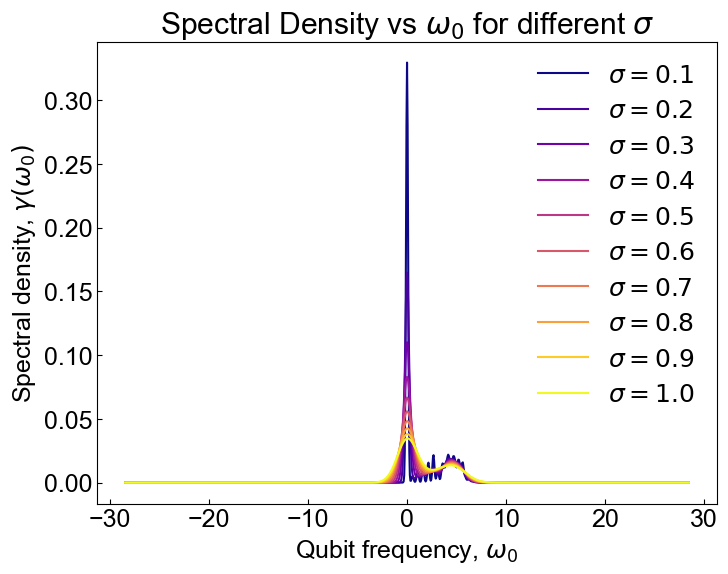

In [6]:
# Examine effect of sigma on result
w0max = np.maximum(np.abs(eigvals[0] - Ebath), np.abs(eigvals[-1] - Ebath))
w0s = np.linspace(-w0max, w0max, 1001)
sigmas = np.arange(0.1, 1.1, 0.1)  # Different values of sigma
cmap = plt.get_cmap("plasma")
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
for i, sigma in enumerate(sigmas):
    gamma = compute_spectral_density(w0s, eigvals, A, g, bath_idx, sigma)
    color = cmap(i / (len(sigmas) - 1))
    ax.plot(w0s, np.abs(gamma), label=fr"$\sigma={sigma:.1f}$", color=color)

ax.set_xlabel(r"Qubit frequency, $\omega_0$")
ax.set_ylabel(r"Spectral density, $\gamma(\omega_0)$")
ax.set_title(r"Spectral Density vs $\omega_0$ for different $\sigma$")
ax.legend(frameon=False)
plt.show()


<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
C:\Users\matan\AppData\Local\Temp\ipykernel_25132\20260341.py:15: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title("Final Z Magnetization from Lindblad Theory (multiple $\sigma$)")
Computing spectral density: 100%|██████████| 1024/1024 [00:00<00:00, 27644.01it/s]


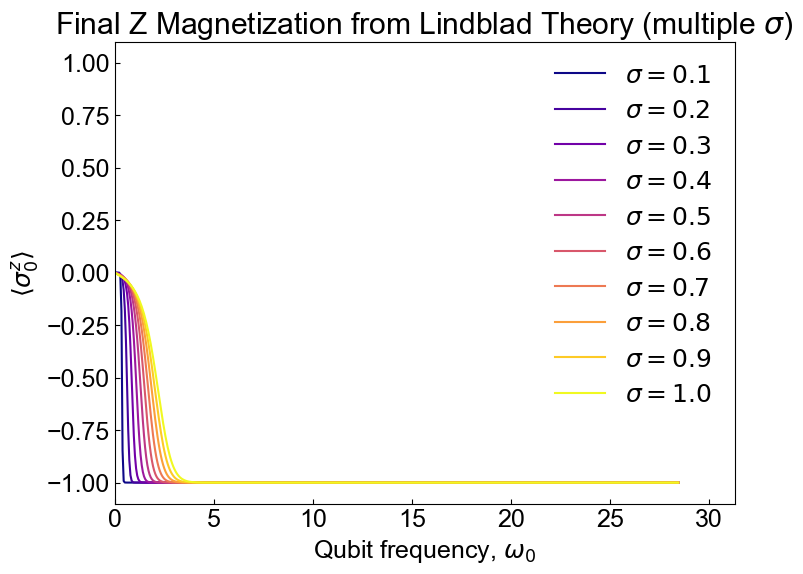

In [7]:
# Plot final z magnetization as predicted by Lindblad theory
z_final_lindblad_dict = {}
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
for i, sigma_val in enumerate(sigmas):
    gamma = compute_spectral_density(w0s, eigvals, A, g, bath_idx, sigma=sigma_val)
    gamma_flipped = np.flip(gamma)
    z_final_lindblad = - (gamma - gamma_flipped) / (gamma + gamma_flipped)
    z_final_lindblad_dict[sigma_val] = z_final_lindblad
    color = cmap(i / (len(sigmas) - 1))
    ax.plot(w0s, z_final_lindblad.real, label=fr"$\sigma={sigma_val:.1f}$", color=color)

ax.set_xlim(left=0)
ax.set_xlabel(r"Qubit frequency, $\omega_0$")
ax.set_ylabel(r"$\langle\sigma_0^z\rangle$")
ax.set_title("Final Z Magnetization from Lindblad Theory (multiple $\sigma$)")
ax.legend(frameon=False)
plt.show()

## Exact evolution vs. Lindblad

In [ ]:
def compute_time_evolution_qubit_pauli(ha, times, qubit_state, bath_state, eigvals=None, eigvecs=None, verbose=False):
    """
    Simulates the time evolution of a qubit coupled to a bath, and computes the expectation values of Pauli operators.

    Parameters:
        ha: HamiltonianAnalyzer object containing the Hamiltonian.
        times: Array of time points for evolution.
        qubit_state: Initial state of the qubit (array-like).
        bath_state: Initial state of the bath (array-like).
        eigvals: Eigenvalues of the Hamiltonian (optional).
        eigvecs: Eigenvectors of the Hamiltonian (optional).
        verbose: If True, prints additional information during computation.

    Returns:
        obs_time: Dictionary with keys "X0", "Y0", "Z0" containing arrays of expectation values over time.
    """
    psi0 = StateGenerator().create_tensor_product_state(
        np.array(qubit_state, dtype=np.complex128), bath_state)

    if eigvals is None or eigvecs is None:
        eigvals, eigvecs = ha.diagonalize(timeit=True)

    obs_dict = {
        "X0": hamiltonian([["x|", [[1.0, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
        "Y0": hamiltonian([["y|", [[1.0j, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
        "Z0": hamiltonian([["z|", [[1.0, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
    }

    obs_time = obs_vs_time(psi_t=(psi0, eigvals, eigvecs),
                           times=times, Obs_dict=obs_dict, verbose=verbose)

    obs_time["Y0"] *= -1.0j  # Convert Y0 back to real values
    for obs in obs_dict:
        obs_time[obs] = np.real(obs_time[obs])

    return obs_time

In [5]:
def compute_pauli_z_lindblad(w0, w0s, gamma, qubit_state, times):
    """
    Computes the time evolution of the qubit's Pauli Z expectation value under Lindblad theory,
    and returns a dictionary with decay rates.

    Parameters:
        w0 (float): Frequency of the qubit.
        w0s (np.ndarray): Array of qubit frequencies for which the spectral density is precomputed.
        gamma (np.ndarray): Array of spectral densities.
        qubit_state (array-like): Initial state of the qubit.
        times (np.ndarray): Array of time points for evolution.

    Returns:
        tuple: (z0, rates_dict)
            z0 (np.ndarray): Time evolution of <sigma_z> as predicted by Lindblad theory.
            rates_dict (dict): Dictionary with keys 'gamma_minus', 'gamma_plus', 'gamma_total'.
    """
    z0i = qubit_state[0] ** 2 - qubit_state[1] ** 2
    gamma_minus = np.interp(w0, w0s, gamma)
    gamma_plus = np.interp(-w0, w0s, gamma)
    gamma_total = gamma_minus + gamma_plus
    z0f = (gamma_plus - gamma_minus) / (gamma_plus + gamma_minus)
    z0 = z0f + (z0i - z0f) * np.exp(-gamma_total * times)
    rates_dict = {
        "minus": gamma_minus.real,
        "plus": gamma_plus.real,
        "total": gamma_total.real
    }
    return z0, rates_dict

def compute_coherence_lindblad(w0, w0s, gamma, qubit_state, times):
    """
    Computes the time evolution of the qubit's coherence (Transverse Pauli expectation value) under Lindblad theory.

    Parameters:
        w0 (float): Frequency of the qubit.
        w0s (np.ndarray): Array of qubit frequencies for which the spectral density is precomputed.
        gamma (np.ndarray): Array of spectral densities.
        qubit_state (array-like): Initial state of the qubit.
        times (np.ndarray): Array of time points for evolution.

    Returns:
        tuple: (coh, rates_dict)
            coh (np.ndarray): Time evolution of |rho12| as predicted by Lindblad theory.
            rates_dict (dict): Dictionary with keys 'gamma_minus', 'gamma_plus', 'gamma_total'.
    """
    c0i = 2 * np.abs(qubit_state[0] * np.conj(qubit_state[1]))
    gamma_minus = np.interp(w0, w0s, gamma)
    gamma_plus = np.interp(-w0, w0s, gamma)
    gamma_total = gamma_minus + gamma_plus
    coh = c0i * np.exp(-gamma_total / 2 * times)
    rates_dict = {
        "minus": gamma_minus.real,
        "plus": gamma_plus.real,
        "total": gamma_total.real
    }
    return coh, rates_dict

def compute_bath_bias(ha_bath, bath_state):
    """
    Computes the expectation value of the bath bias operator Sx1 for a given bath state.

    Parameters:
        ha_bath: HamiltonianAnalyzer object for the bath Hamiltonian.
        bath_state: State vector of the bath.

    Returns:
        float: Expectation value of the Sx1 operator in the given bath state.
    """
    Sx1 = quantum_LinearOperator(
        [["x", [[1.0, 0]]]], basis=ha_bath.basis, dtype=np.complex128, check_symm=False, check_herm=False)
    return Sx1.expt_value(bath_state)

def compute_lindblad_time_evolution(w0, w0s, gamma, g, B, qubit_state, times):
    """
    Computes the time evolution of the qubit's state under Lindblad theory.

    Parameters:
        w0 (float): Frequency of the qubit.
        w0s (np.ndarray): Array of qubit frequencies for which the spectral density is precomputed.
        gamma (np.ndarray): Array of spectral densities.
        g (float): Coupling strength between the qubit and the bath.
        B (float): External field or bias parameter.
        qubit_state (array-like): Initial state of the qubit.
        times (np.ndarray): Array of time points for evolution.

    Returns:
        np.ndarray: Time evolution of the qubit's state.
    """
    # Compute rates gamma "plus" and "minus"
    gamma_minus = np.interp(w0, w0s, gamma)
    gamma_plus = np.interp(-w0, w0s, gamma)

    # Compute initial components
    rhon0 = np.abs(qubit_state[0]) ** 2 - np.abs(qubit_state[1]) ** 2
    rhoc0 = qubit_state[1] * np.conj(qubit_state[0])
    y0 = np.array([rhon0, rhoc0], dtype=np.complex128)

    # Coefficient function
    def coeff_func(t, y):
        rhon, rhoc = y
        drhon_dt = - 2j * g * B * (rhoc - np.conj(rhoc)) - (gamma_minus + gamma_plus) * rhon + (gamma_plus - gamma_minus)
        drhoc_dt = 1j * w0 * rhoc - 1j * g * B * rhon - 0.5 * (gamma_minus + gamma_plus) * rhoc
        return np.array([drhon_dt, drhoc_dt])

    # Solve exact Lindblad evolution
    sol = solve_ivp(coeff_func, (times[0], times[-1]), y0, t_eval=times)

    return sol.y


In [342]:
# Compute time evolution for multiple qubit frequencies
L = 10  # Number of bath sites
hx = 1.1  # X field strength
hz = 0.3  # Z field strength
h1 = 0.25  # Z field strength at the first site (site 0)
hL = -0.25  # Z field strength at the last site (site L-1)
g = 0.15  # Qubit-bath interaction strength
w0s = [0, 0.1, 0.2, 0.5, 1, 1.5, 2, 5, 10]  # Qubit frequencies

# Diagonalize bath Hamiltonian
ha_bath = construct_bath_hamiltonian_analyzer(L, hx, hz, h1, hL)
eigvals_bath, eigvecs_bath = ha_bath.diagonalize(timeit=True)
bath_idx = ha_bath.basis.Ns // 2
# bath_idx = 0
bath_state = eigvecs_bath[:, bath_idx]

qubit_state = [np.sqrt(0.75), np.exp(1j * np.pi / 4) * np.sqrt(0.25)]
# qubit_state = [1 / np.sqrt(2), 1 / np.sqrt(2)]

times = np.linspace(0, 400, 401)  # Time points for evolution

obs_time_list = []

for w0 in tqdm(w0s, desc="Qubit frequencies"):
    ha_total = construct_total_hamiltonian_analyzer(L, hx, hz, h1, hL, g, w0)
    obs_time = compute_time_evolution_qubit_pauli(
        ha=ha_total, times=times, qubit_state=qubit_state, bath_state=bath_state, verbose=True
    )
    obs_time_list.append(obs_time)

Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 1.3944 seconds.


Qubit frequencies:   0%|          | 0/9 [00:00<?, ?it/s]

Hermiticity check passed!


c:\Users\matan\OneDrive - Technion\Graduate\Research\1 Projects\Collapse and Chaos\Code\Python\collapse\core.py:102: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  return hamiltonian(static_list=self.static, dynamic_list=[], basis=self.basis, dtype=np.float64)
c:\Users\matan\OneDrive - Technion\Graduate\Research\1 Projects\Collapse and Chaos\Code\Python\collapse\core.py:102: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  return hamiltonian(static_list=self.static, dynamic_list=[], basis=self.basis, dtype=np.float64)


Diagonalization took 6.3023 seconds.
obs_vs_time integrated to t=1.0000


...

obs_vs_time integrated to t=400.0000
Hermiticity check passed!
Diagonalization took 3.4251 seconds.
obs_vs_time integrated to t=1.0000
obs_vs_time integrated to t=2.0000
obs_vs_time integrated to t=3.0000
obs_vs_time integrated to t=4.0000
obs_vs_time integrated to t=5.0000
obs_vs_time integrated to t=6.0000
obs_vs_time integrated to t=7.0000
obs_vs_time integrated to t=8.0000
obs_vs_time integrated to t=9.0000
obs_vs_time integrated to t=10.0000
obs_vs_time integrated to t=11.0000
obs_vs_time integrated to t=12.0000
obs_vs_time integrated to t=13.0000
obs_vs_time integrated to t=14.0000
obs_vs_time integrated to t=15.0000
obs_vs_time integrated to t=16.0000
obs_vs_time integrated to t=17.0000
obs_vs_time integrated to t=18.0000
obs_vs_time integrated to t=19.0000
obs_vs_time integrated to t=20.0000
obs_vs_time integrated to t=21.0000
obs_vs_time integrated to t=22.0000
obs_vs_time integrated to t=23.0000
obs_vs_time integrated to t=24.0000
obs_vs_time integrated to t=25.0000
obs_vs_ti

Qubit frequencies:  89%|████████▉ | 8/9 [02:57<00:20, 20.74s/it]

obs_vs_time integrated to t=396.0000
obs_vs_time integrated to t=397.0000
obs_vs_time integrated to t=398.0000
obs_vs_time integrated to t=399.0000
obs_vs_time integrated to t=400.0000
Hermiticity check passed!
Diagonalization took 3.4842 seconds.
obs_vs_time integrated to t=1.0000
obs_vs_time integrated to t=2.0000
obs_vs_time integrated to t=3.0000
obs_vs_time integrated to t=4.0000
obs_vs_time integrated to t=5.0000
obs_vs_time integrated to t=6.0000
obs_vs_time integrated to t=7.0000
obs_vs_time integrated to t=8.0000
obs_vs_time integrated to t=9.0000
obs_vs_time integrated to t=10.0000
obs_vs_time integrated to t=11.0000
obs_vs_time integrated to t=12.0000
obs_vs_time integrated to t=13.0000
obs_vs_time integrated to t=14.0000
obs_vs_time integrated to t=15.0000
obs_vs_time integrated to t=16.0000
obs_vs_time integrated to t=17.0000
obs_vs_time integrated to t=18.0000
obs_vs_time integrated to t=19.0000
obs_vs_time integrated to t=20.0000
obs_vs_time integrated to t=21.0000
obs_v

Qubit frequencies: 100%|██████████| 9/9 [03:16<00:00, 21.88s/it]

obs_vs_time integrated to t=396.0000
obs_vs_time integrated to t=397.0000
obs_vs_time integrated to t=398.0000
obs_vs_time integrated to t=399.0000
obs_vs_time integrated to t=400.0000


Computing spectral density: 100%|██████████| 1024/1024 [00:00<00:00, 14916.14it/s]


(-0.016925520344657278+0j)


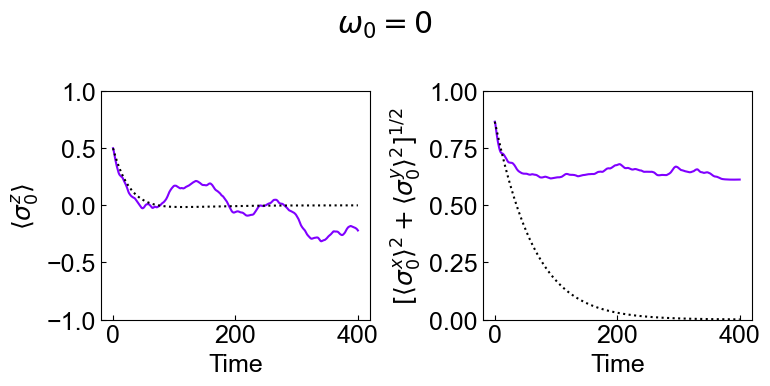

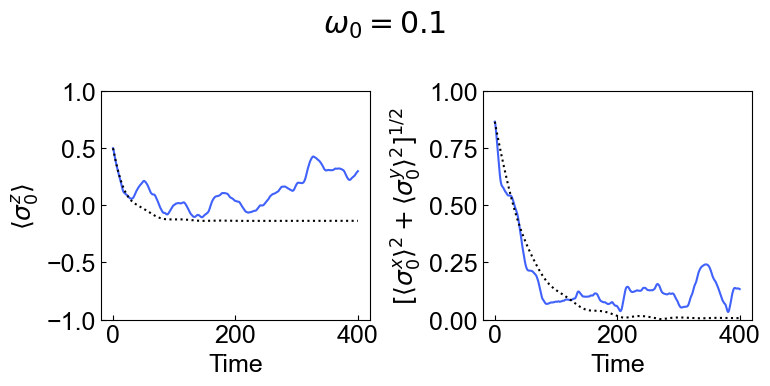

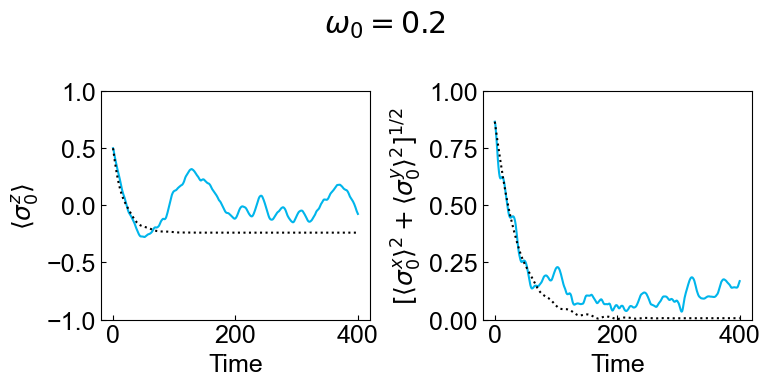

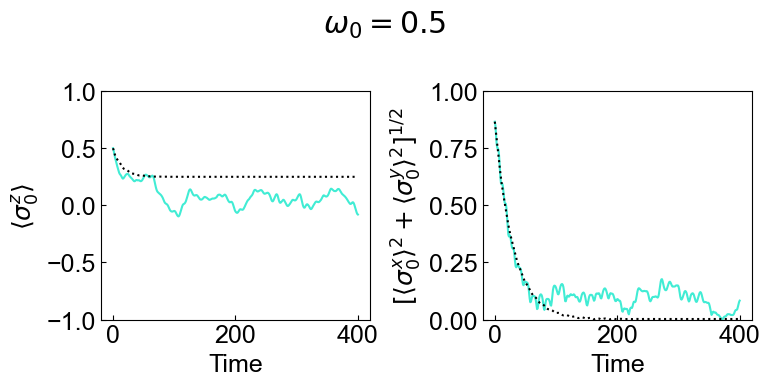

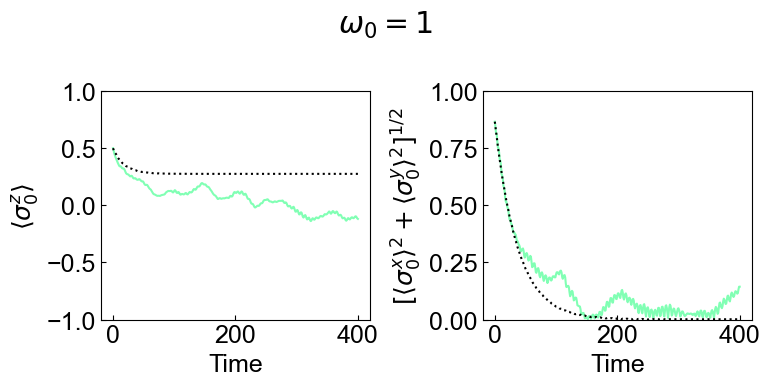

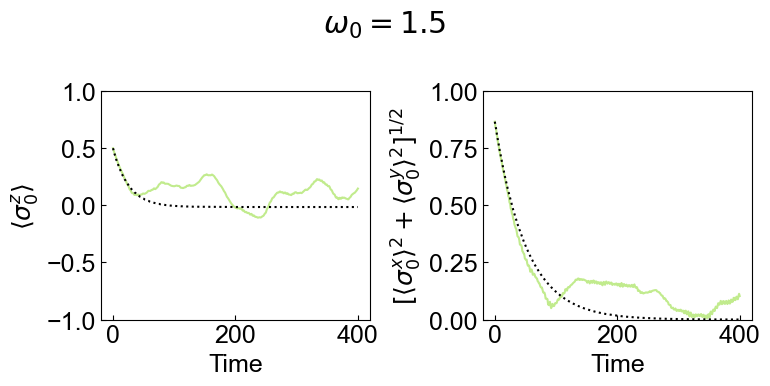

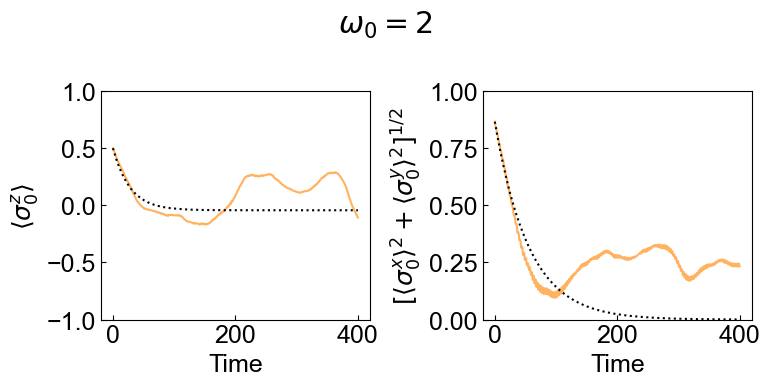

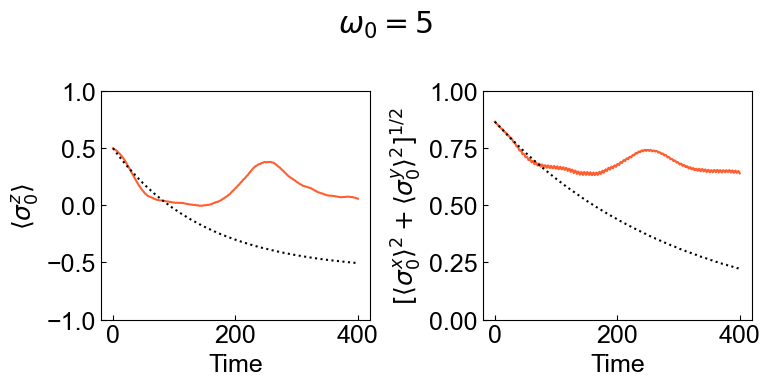

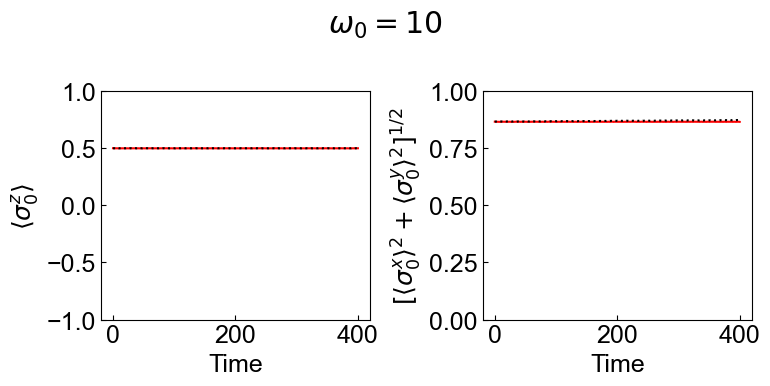

In [353]:
def exp_func(t, xi, xf, g):
    return xi + (xf - xi) * np.exp(-g * t)

z0i = qubit_state[0] ** 2 - qubit_state[1] ** 2
c0i = 2 * np.abs(qubit_state[0] * np.conj(qubit_state[1]))

exp_z0 = lambda t, xi, g: exp_func(t, xi, z0i, g)
exp_c0 = lambda t, xi, g: exp_func(t, xi, c0i, g)

w0s_gamma = np.linspace(-w0s[-1], w0s[-1], 1001)
A = compute_spectral_density_matrix_elements(eigvals_bath, eigvecs_bath, ha_bath.basis, bath_idx=bath_idx)
gamma = compute_spectral_density(w0s_gamma, eigvals_bath, A, g, bath_idx=bath_idx, sigma=.1)

B = compute_bath_bias(ha_bath, bath_state)
print(B)

cmap = plt.get_cmap("rainbow")

fit_max_idx = 100  # Maximum index for fitting
for idx, obs_time in enumerate(obs_time_list):
    w0_val = w0s[idx]
    coherence = np.sqrt(obs_time["X0"] ** 2 + obs_time["Y0"] ** 2)

    # Exact Lindblad solution
    y = compute_lindblad_time_evolution(
        w0=w0_val, w0s=w0s_gamma, gamma=gamma, g=g, B=B, qubit_state=qubit_state, times=times
    )

    z0_lindblad, c0_lindblad = y[0], 2 * y[1]

    # popt_z, _ = curve_fit(exp_z0, times[:fit_max_idx], obs_time["Z0"][:fit_max_idx], p0=[0, z0_rates["total"]])
    # popt_c, _ = curve_fit(exp_c0, times[:fit_max_idx], coherence[:fit_max_idx], p0=[0, c0_rates["total"]])

    fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=100)

    axs[0].plot(times, obs_time["Z0"], color=cmap(idx / (len(w0s) - 1)), label="Exact")
    # axs[0].plot(times, exp_z0(times, *popt_z), color="k", linestyle="--", label="Exp. fit")
    axs[0].plot(times, z0_lindblad, color="k", linestyle=":", label="Lindblad exp.")

    axs[1].plot(times, coherence, color=cmap(idx / (len(w0s) - 1)), label="Exact")
    # axs[1].plot(times, exp_c0(times, *popt_c), color="k", linestyle="--", label="Exp. fit")
    axs[1].plot(times, np.abs(c0_lindblad), color="k", linestyle=":", label="Lindblad exp.")

    axs[0].set_ylim(-1, 1)
    axs[1].set_ylim(0, 1)
    axs[0].set_xlabel("Time")
    axs[1].set_xlabel("Time")
    axs[0].set_ylabel(r"$\langle \sigma_0^z \rangle$")
    axs[1].set_ylabel(r"$[\langle \sigma_0^x \rangle^2 + \langle \sigma_0^y \rangle^2]^{1/2}$")
    fig.suptitle(f"$\\omega_0 = {w0s[idx]}$")
    # axs[0].legend(loc="upper right")
    # axs[1].legend(loc="upper right")
    plt.tight_layout(pad=1.0)
    plt.show()


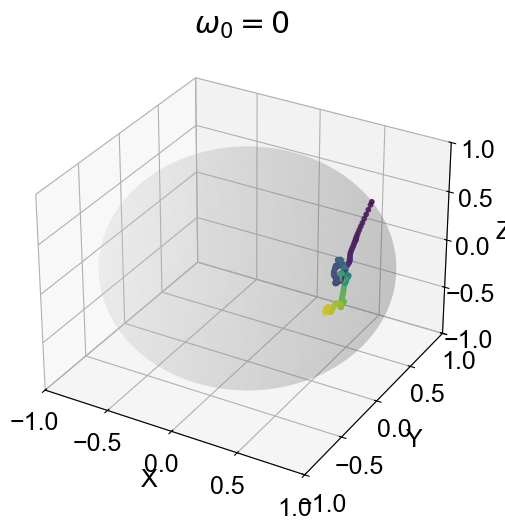

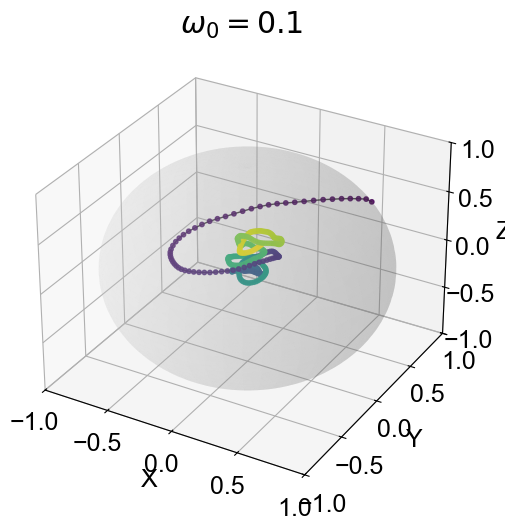

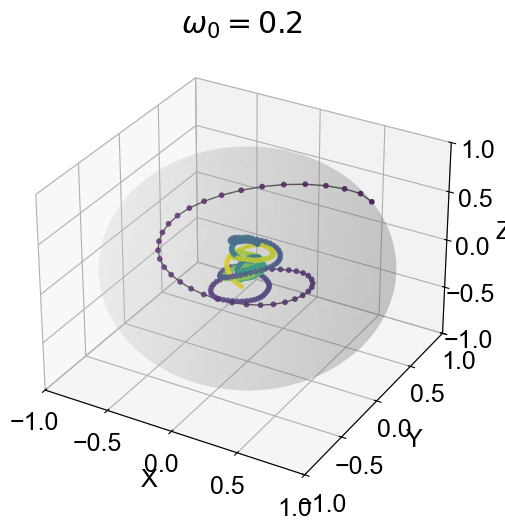

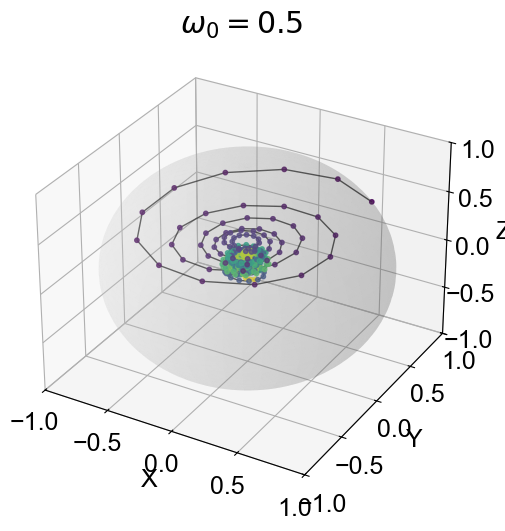

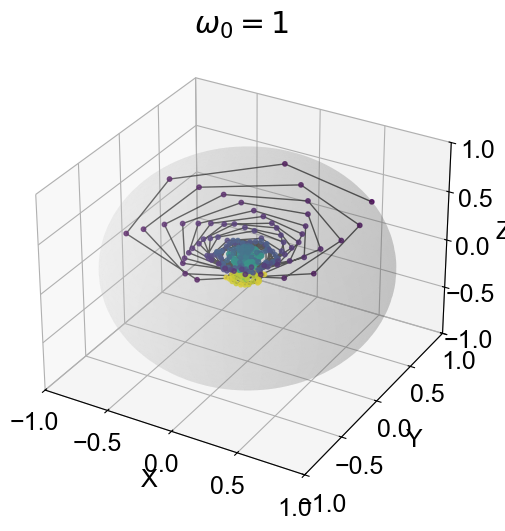

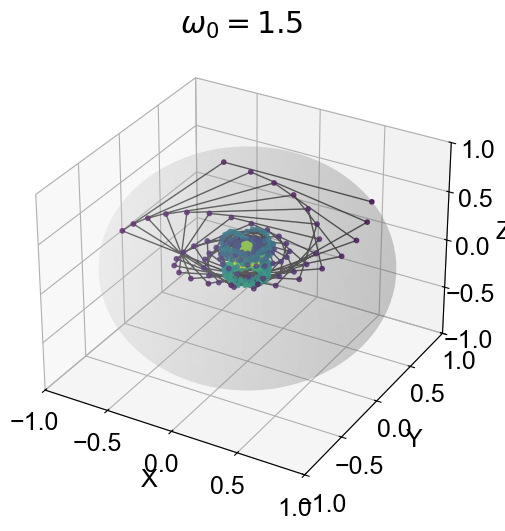

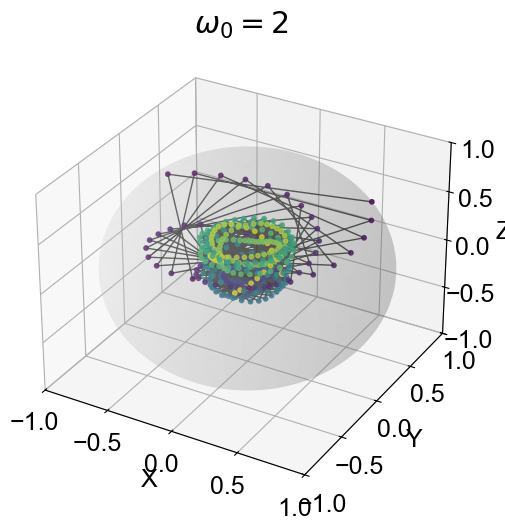

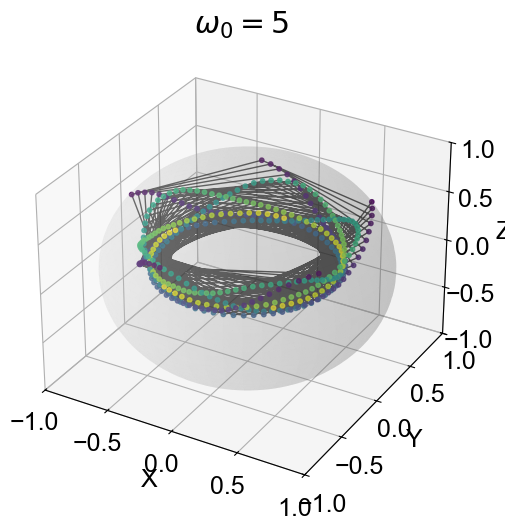

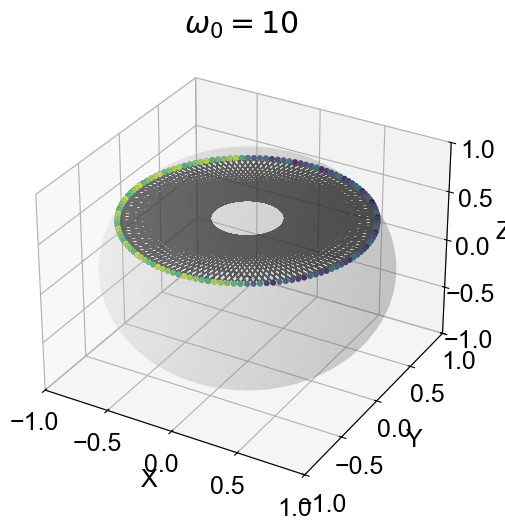

In [ ]:
# Plot the qubit on the Bloch ball for each qubit frequency
for idx, obs_time in enumerate(obs_time_list):
    fig = plt.figure(figsize=(6, 6), dpi=100)
    ax = fig.add_subplot(111, projection="3d")

    # Plot the Bloch ball
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(x, y, z, color="lightgray", alpha=0.15)

    # Plot the qubit state on the Bloch ball
    ax.plot(
        obs_time["X0"],
        obs_time["Y0"],
        obs_time["Z0"],
        color="black",
        linewidth=1,
        alpha=0.7
    )
    bloch_vector = [obs_time["X0"], obs_time["Y0"], obs_time["Z0"]]
    colors = plt.cm.viridis(np.linspace(0, 1, len(bloch_vector[0])))
    ax.scatter(
        obs_time["X0"],
        obs_time["Y0"],
        obs_time["Z0"],
        c=colors,
        s=10,
        alpha=0.8
    )

    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(f"$\\omega_0 = {w0s[idx]}$")
    plt.show()

In [ ]:
# Plot exponential decay rate vs. qubit frequency
z_rates, coh_rates = [], []
fit_max_idx = 100  # Maximum index for fitting
for idx, obs_time in enumerate(obs_time_list[:-2]):
    popt_z, _ = curve_fit(exp_func, times[:fit_max_idx], obs_time["Z0"][:fit_max_idx], p0=[0, 0.5, 0.01])
    z_rates.append(popt_z[2])
    coherence = np.sqrt(np.abs(obs_time["X0"]) ** 2 + np.abs(obs_time["Y0"]) ** 2)
    popt_coh, _ = curve_fit(exp_func, times[:fit_max_idx], coherence[:fit_max_idx], p0=[0, 0.5, 0.01])
    coh_rates.append(popt_coh[2])

rate_ratio = np.array(z_rates) / np.array(coh_rates)

fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=100)

axs[0].plot(w0s[:-2], z_rates, marker="o", linestyle="--", label=r"$\gamma_z$")
axs[0].plot(w0s[:-2], coh_rates, marker="o", linestyle="--", label=r"$\gamma_{\mathrm{coh}}$")
axs[0].set_xticks(np.arange(0, 2.1, 0.5))
axs[0].set_xlabel(r"$\omega_0$")
axs[0].set_ylabel(r"Decay Rate $\gamma$")
axs[0].legend()

axs[1].plot(w0s[:-2], rate_ratio, marker="o", linestyle="--", color="C2")
axs[1].axhline(2, color="k", linestyle=":")
axs[1].set_xticks(np.arange(0, 2.1, 0.5))
axs[1].set_xlabel(r"$\omega_0$")
axs[1].set_xlabel(r"$\omega_0$")
axs[1].set_ylabel(r"Rate Ratio $\gamma_z/\gamma_{\mathrm{coh}}$")
axs[1].set_yticks([2, 5, 10, 20])

plt.tight_layout()
plt.show()

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.

Computing spectral density: 100%|██████████| 8192/8192 [00:00<00:00, 12418.15it/s]


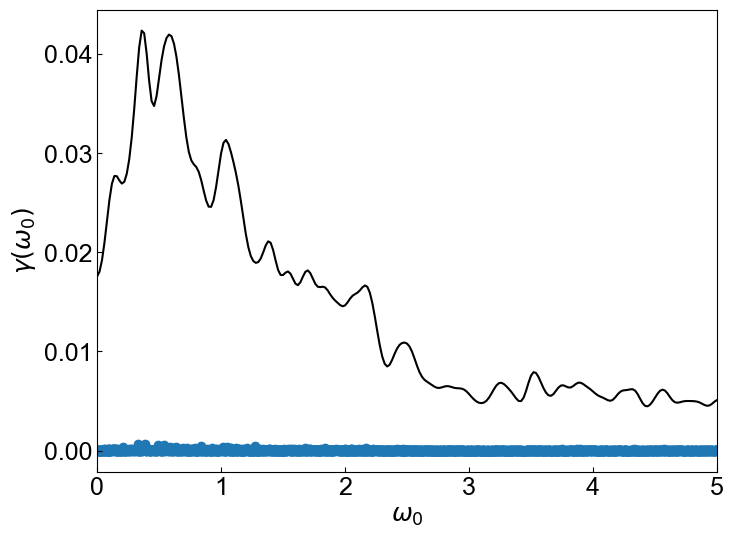

In [289]:
# Plot spectral function and mark selected qubit frequencies
w0s_gamma = np.linspace(-w0s[-1], w0s[-1], 1001)
A = compute_spectral_density_matrix_elements(eigvals_bath, eigvecs_bath, ha_bath.basis, bath_idx=bath_idx)
gamma = compute_spectral_density(w0s_gamma, eigvals_bath, A, g, bath_idx=bath_idx, sigma=0.05)
Ebath = eigvals_bath[bath_idx]

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.plot(w0s_gamma, gamma, color="k", label="Spectral function (Gaussian broadening)")
ax.scatter(eigvals_bath - eigvals_bath[bath_idx], 2 * np.pi * np.abs(g) ** 2 * A)
ax.set_xlim(0, 5)
ax.set_xlabel(r"$\omega_0$")
ax.set_ylabel(r"$\gamma(\omega_0)$")
plt.show()

In [67]:
# Plot Lindbladian spectral function compared to the rates extracted from the exact dynamics
w0s_gamma = np.linspace(-w0s[-1], w0s[-1], 1001)
A = compute_spectral_density_matrix_elements(eigvals_bath, eigvecs_bath, ha_bath.basis, bath_idx=bath_idx)
gamma = compute_spectral_density(w0s_gamma, eigvals_bath, A, g, bath_idx=bath_idx, sigma=0.1)


gamma_plus_exact_list, gamma_minus_exact_list = [], []
for obs_time in obs_time_list[:-2]:
    coherence = np.sqrt(np.abs(obs_time["X0"]) ** 2 + np.abs(obs_time["Y0"]) ** 2)
    popt_coh, _ = curve_fit(exp_func, times, coherence, p0=[0, 0.5, 0.01])
    c_coh = popt_coh[2]
    print(c_coh)
    # gamma_plus_exact = 0.5 * (az * cz + cz)
    # gamma_minus_exact = cz - gamma_plus_exact
    gamma_plus_exact_list.append(c_coh)
    gamma_minus_exact_list.append(c_coh)

w0_arr_pos = np.array(w0s[:-2])
gamma_plus_exact_arr, gamma_minus_exact_arr = np.array(gamma_plus_exact_list), np.array(gamma_minus_exact_list)
gamma_exact_arr = np.concatenate([np.flip(gamma_minus_exact_arr[1:]), gamma_plus_exact_arr])
w0_arr = np.concatenate([np.flip(-w0_arr_pos[1:]), w0_arr_pos])

fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
ax.plot(w0_arr, gamma_exact_arr, marker="o", linestyle="--", label=r"$\gamma_z^{\mathrm{exact}}$")
ax.plot(w0s_gamma, np.abs(gamma), label=r"$\gamma(\omega_0)$", color="k")
ax.set_xlim(-3, 3)
ax.set_xlabel(r"$\omega_0$")
ax.set_ylabel(r"$\gamma(\omega_0)$")
ax.legend()
plt.show()

Computing spectral density: 100%|██████████| 1024/1024 [00:00<00:00, 27115.55it/s]


RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.

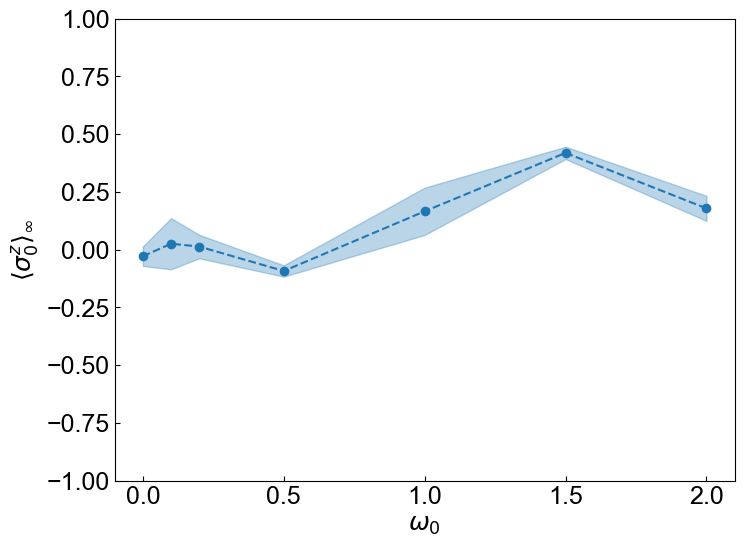

In [17]:
# Compute steady-state <Z>, estimated by averaging over long times
Z_ss = [np.mean(obs_time["Z0"][-100:]) for obs_time in obs_time_list[:-2]]
Z_ss_std = [np.std(obs_time["Z0"][-100:]) for obs_time in obs_time_list[:-2]]

# Visualize results
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
ax.plot(w0s[:-2], Z_ss, color="C0", marker="o", linestyle="--")
ax.fill_between(w0s[:-2], np.array(Z_ss) - np.array(Z_ss_std), np.array(Z_ss) + np.array(Z_ss_std),
                color="C0", alpha=0.3)
ax.set_ylim(-1, 1)
ax.set_xticks(np.arange(0, 2.1, 0.5))
ax.set_xlabel(r"$\omega_0$")
ax.set_ylabel(r"$\langle \sigma_0^z \rangle_{\infty}$")
plt.show()

In [ ]:
# Repeat for multiple qubit-bath interaction strengths
L = 10  # Number of bath sites
hx = 1.1  # X field strength
hz = 0.3  # Z field strength
h1 = 0.25  # Z field strength at the first site (site 0)
hL = -0.25  # Z field strength at the last site (site L-1)
gs = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10]  # Qubit-bath interaction strengths
w0 = 1.525  # Qubit frequency

# Diagonalize bath Hamiltonian
ha_bath = construct_bath_hamiltonian_analyzer(L, hx, hz, h1, hL)
eigvals_bath, eigvecs_bath = ha_bath.diagonalize(timeit=True)
bath_idx = ha_bath.basis.Ns // 2
bath_state = eigvecs_bath[:, bath_idx]

qubit_state = [np.sqrt(0.75), np.sqrt(0.25)]

times = np.linspace(0, 400, 401)  # Time points for evolution

obs_time_list = []

for g in tqdm(gs, desc="Qubit-bath interaction strengths"):
    ha_total = construct_total_hamiltonian_analyzer(L, hx, hz, h1, hL, g, w0)
    obs_time = compute_time_evolution_qubit_pauli(
        ha=ha_total, times=times, qubit_state=qubit_state, bath_state=bath_state, verbose=True
    )
    obs_time_list.append(obs_time)

Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 0.7273 seconds.


Qubit-bath interaction strengths:   0%|          | 0/10 [00:00<?, ?it/s]

Hermiticity check passed!
Diagonalization took 4.8796 seconds.


C:\Users\matan\AppData\Local\Temp\ipykernel_24324\2178716721.py:24: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  "X0": hamiltonian([["x|", [[1.0, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
C:\Users\matan\AppData\Local\Temp\ipykernel_24324\2178716721.py:25: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  "Y0": hamiltonian([["y|", [[1.0j, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
C:\Users\matan\AppData\Local\Temp\ipykernel_24324\2178716721.py:26: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  "Z0": hamiltonian([["z|", [[1.0, 0]]]], [], ba

obs_vs_time integrated to t=1.0000
obs_vs_time integrated to t=2.0000
obs_vs_time integrated to t=3.0000
obs_vs_time integrated to t=4.0000
obs_vs_time integrated to t=5.0000
obs_vs_time integrated to t=6.0000
obs_vs_time integrated to t=7.0000
obs_vs_time integrated to t=8.0000
obs_vs_time integrated to t=9.0000
obs_vs_time integrated to t=10.0000
obs_vs_time integrated to t=11.0000
obs_vs_time integrated to t=12.0000
obs_vs_time integrated to t=13.0000
obs_vs_time integrated to t=14.0000
obs_vs_time integrated to t=15.0000
obs_vs_time integrated to t=16.0000
obs_vs_time integrated to t=17.0000
obs_vs_time integrated to t=18.0000
obs_vs_time integrated to t=19.0000
obs_vs_time integrated to t=20.0000
obs_vs_time integrated to t=21.0000
obs_vs_time integrated to t=22.0000
obs_vs_time integrated to t=23.0000
obs_vs_time integrated to t=24.0000
obs_vs_time integrated to t=25.0000
obs_vs_time integrated to t=26.0000
obs_vs_time integrated to t=27.0000
obs_vs_time integrated to t=28.0000
o

...

obs_vs_time integrated to t=397.0000
obs_vs_time integrated to t=398.0000
obs_vs_time integrated to t=399.0000
obs_vs_time integrated to t=400.0000
Hermiticity check passed!
Diagonalization took 4.1599 seconds.
obs_vs_time integrated to t=1.0000
obs_vs_time integrated to t=2.0000
obs_vs_time integrated to t=3.0000
obs_vs_time integrated to t=4.0000
obs_vs_time integrated to t=5.0000
obs_vs_time integrated to t=6.0000
obs_vs_time integrated to t=7.0000
obs_vs_time integrated to t=8.0000
obs_vs_time integrated to t=9.0000
obs_vs_time integrated to t=10.0000
obs_vs_time integrated to t=11.0000
obs_vs_time integrated to t=12.0000
obs_vs_time integrated to t=13.0000
obs_vs_time integrated to t=14.0000
obs_vs_time integrated to t=15.0000
obs_vs_time integrated to t=16.0000
obs_vs_time integrated to t=17.0000
obs_vs_time integrated to t=18.0000
obs_vs_time integrated to t=19.0000
obs_vs_time integrated to t=20.0000
obs_vs_time integrated to t=21.0000
obs_vs_time integrated to t=22.0000
obs_vs

Qubit-bath interaction strengths:  90%|█████████ | 9/10 [03:45<00:26, 26.24s/it]

obs_vs_time integrated to t=398.0000
obs_vs_time integrated to t=399.0000
obs_vs_time integrated to t=400.0000
Hermiticity check passed!
Diagonalization took 4.2413 seconds.
obs_vs_time integrated to t=1.0000
obs_vs_time integrated to t=2.0000
obs_vs_time integrated to t=3.0000
obs_vs_time integrated to t=4.0000
obs_vs_time integrated to t=5.0000
obs_vs_time integrated to t=6.0000
obs_vs_time integrated to t=7.0000
obs_vs_time integrated to t=8.0000
obs_vs_time integrated to t=9.0000
obs_vs_time integrated to t=10.0000
obs_vs_time integrated to t=11.0000
obs_vs_time integrated to t=12.0000
obs_vs_time integrated to t=13.0000
obs_vs_time integrated to t=14.0000
obs_vs_time integrated to t=15.0000
obs_vs_time integrated to t=16.0000
obs_vs_time integrated to t=17.0000
obs_vs_time integrated to t=18.0000
obs_vs_time integrated to t=19.0000
obs_vs_time integrated to t=20.0000
obs_vs_time integrated to t=21.0000
obs_vs_time integrated to t=22.0000
obs_vs_time integrated to t=23.0000
obs_vs_

Qubit-bath interaction strengths: 100%|██████████| 10/10 [04:09<00:00, 24.95s/it]

obs_vs_time integrated to t=396.0000
obs_vs_time integrated to t=397.0000
obs_vs_time integrated to t=398.0000
obs_vs_time integrated to t=399.0000
obs_vs_time integrated to t=400.0000


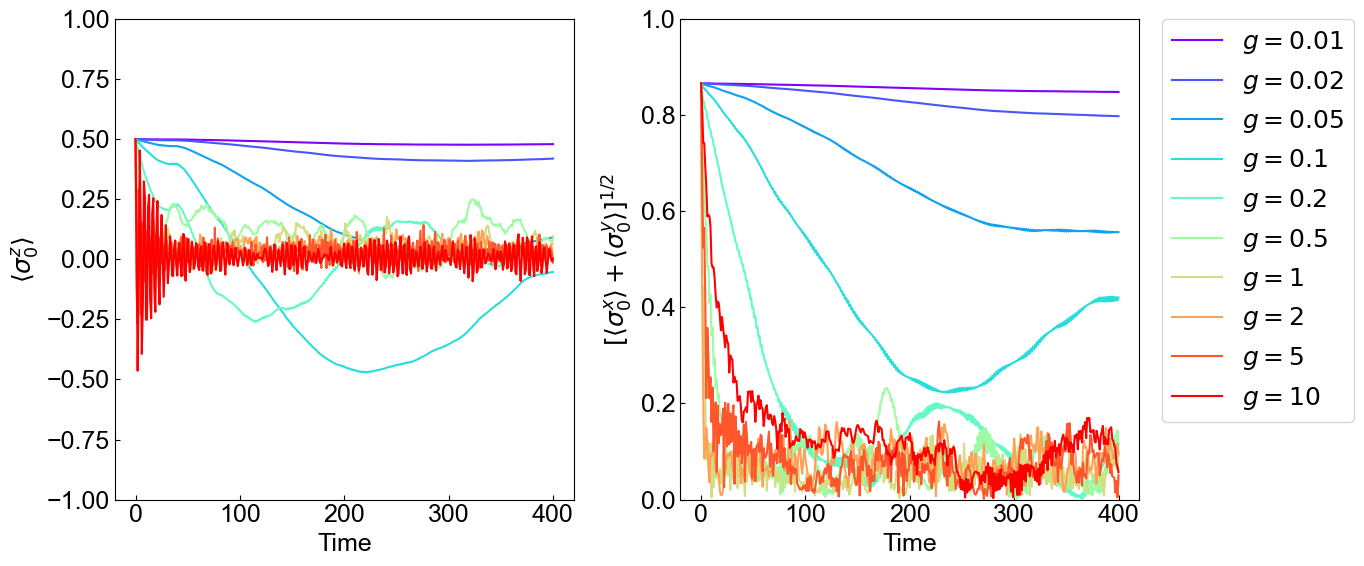

In [70]:
# Visualize the time evolution for multiple interaction strengths
cmap = plt.get_cmap("rainbow")
fig, axs = plt.subplots(1, 2, figsize=(14, 6), dpi=100)
for idx, obs_time in enumerate(obs_time_list):
    axs[0].plot(times, obs_time["Z0"], label=f"$g={gs[idx]}$", color=cmap(idx / (len(gs) - 1)))
    axs[1].plot(times, np.sqrt(np.abs(obs_time["X0"]) ** 2 + np.abs(obs_time["Y0"]) ** 2), color=cmap(idx / (len(gs) - 1)), label=f"$g={gs[idx]}$")
axs[0].set_ylim(-1, 1)
axs[0].set_xlabel("Time")
axs[0].set_ylabel(r"$\langle \sigma_0^z \rangle$")
axs[1].set_ylim(0, 1)
axs[1].set_xlabel("Time")
axs[1].set_ylabel(r"$[\langle \sigma_0^x \rangle + \langle \sigma_0^y \rangle]^{1/2}$")
axs[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)
plt.tight_layout()
plt.show()

In [91]:
# Repeat for multiple initial bath states
L = 12  # Number of bath sites
hx = 1.1  # X field strength
hz = 0.3  # Z field strength
h1 = 0.25  # Z field strength at the first site (site 0)
hL = -0.25  # Z field strength at the last site (site L-1)
g = 0.15  # Coupling strength between the qubit and the bath
w0 = 1.525  # Qubit frequency

# Diagonalize the bath Hamiltonian
ha_bath = construct_bath_hamiltonian_analyzer(L, hx, hz, h1, hL)
eigvals_bath, eigvecs_bath = ha_bath.diagonalize(timeit=True)

# Initial qubit state
qubit_state = [np.sqrt(0.75), np.sqrt(0.25)]

# Indices for initial bath state (out of bath eigenbasis)
M = ha_bath.basis.Ns
bath_idxs = np.array([0, 1, np.floor(0.25 * M), np.floor(0.5 * M) - 1, np.floor(0.5 * M), np.floor(0.75 * M), M - 2, M - 1], dtype=int)

# Compute time evolution of the qubit Pauli operators
times = np.linspace(0, 400, 101)  # Time points for evolution
obs_time_list = []
for idx in tqdm(bath_idxs, desc="Bath states"):
    bath_state = eigvecs_bath[:, idx]
    ha_total = construct_total_hamiltonian_analyzer(L, hx, hz, h1, hL, g, w0)
    obs_time = compute_time_evolution_qubit_pauli(
        ha=ha_total, times=times, qubit_state=qubit_state, bath_state=bath_state, verbose=True
    )
    obs_time_list.append(obs_time)

Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 64.7943 seconds.


Bath states:   0%|          | 0/8 [00:00<?, ?it/s]

Hermiticity check passed!
Diagonalization took 155.4684 seconds.


C:\Users\matan\AppData\Local\Temp\ipykernel_24324\2178716721.py:24: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  "X0": hamiltonian([["x|", [[1.0, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
C:\Users\matan\AppData\Local\Temp\ipykernel_24324\2178716721.py:25: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  "Y0": hamiltonian([["y|", [[1.0j, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
C:\Users\matan\AppData\Local\Temp\ipykernel_24324\2178716721.py:26: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  "Z0": hamiltonian([["z|", [[1.0, 0]]]], [], ba

obs_vs_time integrated to t=4.0000
obs_vs_time integrated to t=8.0000
obs_vs_time integrated to t=12.0000
obs_vs_time integrated to t=16.0000
obs_vs_time integrated to t=20.0000
obs_vs_time integrated to t=24.0000
obs_vs_time integrated to t=28.0000
obs_vs_time integrated to t=32.0000
obs_vs_time integrated to t=36.0000
obs_vs_time integrated to t=40.0000
obs_vs_time integrated to t=44.0000
obs_vs_time integrated to t=48.0000
obs_vs_time integrated to t=52.0000
obs_vs_time integrated to t=56.0000
obs_vs_time integrated to t=60.0000
obs_vs_time integrated to t=64.0000
obs_vs_time integrated to t=68.0000
obs_vs_time integrated to t=72.0000
obs_vs_time integrated to t=76.0000
obs_vs_time integrated to t=80.0000
obs_vs_time integrated to t=84.0000
obs_vs_time integrated to t=88.0000
obs_vs_time integrated to t=92.0000
obs_vs_time integrated to t=96.0000
obs_vs_time integrated to t=100.0000
obs_vs_time integrated to t=104.0000
obs_vs_time integrated to t=108.0000
obs_vs_time integrated to t

...

obs_vs_time integrated to t=400.0000
Hermiticity check passed!
Diagonalization took 214.0973 seconds.
obs_vs_time integrated to t=4.0000
obs_vs_time integrated to t=8.0000
obs_vs_time integrated to t=12.0000
obs_vs_time integrated to t=16.0000
obs_vs_time integrated to t=20.0000
obs_vs_time integrated to t=24.0000
obs_vs_time integrated to t=28.0000
obs_vs_time integrated to t=32.0000
obs_vs_time integrated to t=36.0000
obs_vs_time integrated to t=40.0000
obs_vs_time integrated to t=44.0000
obs_vs_time integrated to t=48.0000
obs_vs_time integrated to t=52.0000
obs_vs_time integrated to t=56.0000
obs_vs_time integrated to t=60.0000
obs_vs_time integrated to t=64.0000
obs_vs_time integrated to t=68.0000
obs_vs_time integrated to t=72.0000
obs_vs_time integrated to t=76.0000
obs_vs_time integrated to t=80.0000
obs_vs_time integrated to t=84.0000
obs_vs_time integrated to t=88.0000
obs_vs_time integrated to t=92.0000
obs_vs_time integrated to t=96.0000
obs_vs_time integrated to t=100.0000

Bath states:  88%|████████▊ | 7/8 [27:28<04:22, 262.96s/it]

obs_vs_time integrated to t=400.0000
Hermiticity check passed!
Diagonalization took 228.9003 seconds.
obs_vs_time integrated to t=4.0000
obs_vs_time integrated to t=8.0000
obs_vs_time integrated to t=12.0000
obs_vs_time integrated to t=16.0000
obs_vs_time integrated to t=20.0000
obs_vs_time integrated to t=24.0000
obs_vs_time integrated to t=28.0000
obs_vs_time integrated to t=32.0000
obs_vs_time integrated to t=36.0000
obs_vs_time integrated to t=40.0000
obs_vs_time integrated to t=44.0000
obs_vs_time integrated to t=48.0000
obs_vs_time integrated to t=52.0000
obs_vs_time integrated to t=56.0000
obs_vs_time integrated to t=60.0000
obs_vs_time integrated to t=64.0000
obs_vs_time integrated to t=68.0000
obs_vs_time integrated to t=72.0000
obs_vs_time integrated to t=76.0000
obs_vs_time integrated to t=80.0000
obs_vs_time integrated to t=84.0000
obs_vs_time integrated to t=88.0000
obs_vs_time integrated to t=92.0000
obs_vs_time integrated to t=96.0000
obs_vs_time integrated to t=100.0000

Bath states: 100%|██████████| 8/8 [32:43<00:00, 245.49s/it]

obs_vs_time integrated to t=400.0000


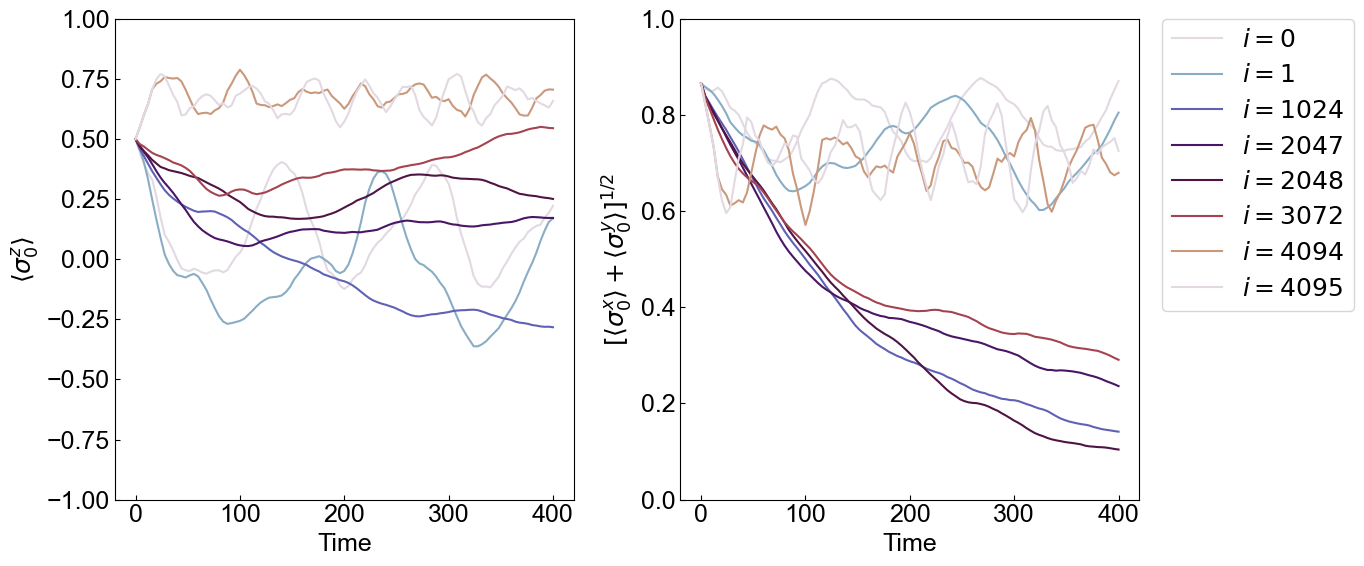

In [ ]:
# Visualize the time evolution for multiple initial bath states
cmap = plt.get_cmap("twilight")
fig, axs = plt.subplots(1, 2, figsize=(14, 6), dpi=100)
for idx, obs_time in enumerate(obs_time_list):
    axs[0].plot(times, obs_time["Z0"], label=f"$i={bath_idxs[idx]}$", color=cmap(idx / (len(bath_idxs) - 1)))
    axs[1].plot(times, np.sqrt(np.abs(obs_time["X0"]) ** 2 + np.abs(obs_time["Y0"]) ** 2), color=cmap(idx / (len(bath_idxs) - 1)), label=f"$i={bath_idxs[idx]}$")
axs[0].set_ylim(-1, 1)
axs[0].set_xlabel("Time")
axs[0].set_ylabel(r"$\langle \sigma_0^z \rangle$")
axs[1].set_ylim(0, 1)
axs[1].set_xlabel("Time")
axs[1].set_ylabel(r"$[\langle \sigma_0^x \rangle + \langle \sigma_0^y \rangle]^{1/2}$")
axs[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)
plt.tight_layout()
plt.show()

In [145]:
# Compute expectation value of Sx for the bath eigenstates
L = 12  # Number of bath sites
hx = 1.1  # X field strength
hz = 0.3  # Z field strength
h1 = 0.25  # Z field strength at the first site (site 0)
hL = -0.25  # Z field strength at the last site (site L-1)
g = 0.015  # Qubit-bath interaction strength
w0 = 1.525  # Qubit frequency

# Diagonalize bath Hamiltonian
ha_bath = construct_bath_hamiltonian_analyzer(L, hx, hz, h1, hL)
eigvals_bath, eigvecs_bath = ha_bath.diagonalize(timeit=True)

Sx1_expt_vals = []
Sx1 = quantum_LinearOperator(
        [["x", [[1.0, 0]]]], basis=ha_bath.basis, dtype=np.complex128, check_symm=False, check_herm=False)
for i in tqdm(range(len(eigvals_bath)), desc="Computing <Sx> expectation values"):
        Sx1_expt_vals.append(Sx1.expt_value(eigvecs_bath[:, i]))

Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 36.4967 seconds.


Computing <Sx> expectation values: 100%|██████████| 4096/4096 [00:05<00:00, 746.08it/s] 


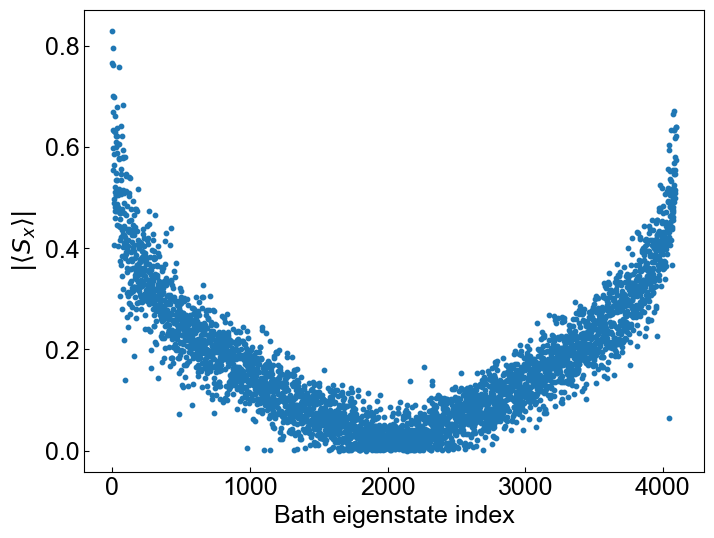

In [146]:
# Plot absolute value of Sx1 expectation value vs. eigenstate index
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.scatter(np.arange(len(Sx1_expt_vals)), np.abs(Sx1_expt_vals), s=10)
ax.set_xlabel("Bath eigenstate index")
ax.set_ylabel(r"$|\langle S_x \rangle|$")
plt.show()

In [6]:
# Compute evolution of thermal state
L = 10  # Number of bath sites
hx = 1.1  # X field strength
hz = 0.3  # Z field strength
h1 = 0.25  # Z field strength at the first site (site 0)
hL = -0.25  # Z field strength at the last site (site L-1)
g = 0.15  # Coupling strength between the qubit and the bath
w0 = 1.525  # Qubit frequency

# Diagonalize bath Hamiltonian
ha_bath = construct_bath_hamiltonian_analyzer(L, hx, hz, h1, hL)
eigvals_bath, eigvecs_bath = ha_bath.diagonalize(timeit=True)

# Initialize bath in thermal state (as density matrix)
beta = 0.25  # Inverse temperature
bath_state = StateGenerator().create_thermal_state_pure(beta, eigvals_bath, eigvecs_bath)

# Initial qubit state
qubit_state = [np.sqrt(0.75), np.sqrt(0.25)]

times = np.linspace(0, 400, 401)  # Time points for evolution

ha_total = construct_total_hamiltonian_analyzer(L, hx, hz, h1, hL, g, w0)
obs_time = compute_time_evolution_qubit_pauli(
    ha=ha_total, times=times, qubit_state=qubit_state, bath_state=bath_state, verbose=True
)

Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 1.4113 seconds.
Hermiticity check passed!


c:\Users\matan\OneDrive - Technion\Graduate\Research\1 Projects\Collapse and Chaos\Code\Python\collapse\core.py:102: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  return hamiltonian(static_list=self.static, dynamic_list=[], basis=self.basis, dtype=np.float64)
c:\Users\matan\OneDrive - Technion\Graduate\Research\1 Projects\Collapse and Chaos\Code\Python\collapse\core.py:102: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  return hamiltonian(static_list=self.static, dynamic_list=[], basis=self.basis, dtype=np.float64)


Diagonalization took 4.3371 seconds.


C:\Users\matan\AppData\Local\Temp\ipykernel_40912\2178716721.py:24: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  "X0": hamiltonian([["x|", [[1.0, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
C:\Users\matan\AppData\Local\Temp\ipykernel_40912\2178716721.py:25: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  "Y0": hamiltonian([["y|", [[1.0j, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
C:\Users\matan\AppData\Local\Temp\ipykernel_40912\2178716721.py:26: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  "Z0": hamiltonian([["z|", [[1.0, 0]]]], [], ba

obs_vs_time integrated to t=1.0000
obs_vs_time integrated to t=2.0000
obs_vs_time integrated to t=3.0000
obs_vs_time integrated to t=4.0000
obs_vs_time integrated to t=5.0000
obs_vs_time integrated to t=6.0000
obs_vs_time integrated to t=7.0000
obs_vs_time integrated to t=8.0000
obs_vs_time integrated to t=9.0000
obs_vs_time integrated to t=10.0000
obs_vs_time integrated to t=11.0000
obs_vs_time integrated to t=12.0000
obs_vs_time integrated to t=13.0000
obs_vs_time integrated to t=14.0000
obs_vs_time integrated to t=15.0000
obs_vs_time integrated to t=16.0000
obs_vs_time integrated to t=17.0000
obs_vs_time integrated to t=18.0000
obs_vs_time integrated to t=19.0000
obs_vs_time integrated to t=20.0000
obs_vs_time integrated to t=21.0000
obs_vs_time integrated to t=22.0000
obs_vs_time integrated to t=23.0000
obs_vs_time integrated to t=24.0000
obs_vs_time integrated to t=25.0000
obs_vs_time integrated to t=26.0000
obs_vs_time integrated to t=27.0000
obs_vs_time integrated to t=28.0000
o

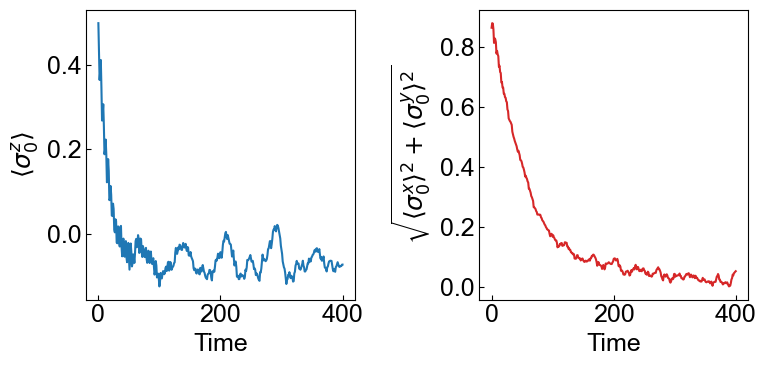

In [8]:
# Visualize time evolution
fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=100)

# Plot <Z>
axs[0].plot(times, obs_time["Z0"], color="C0")
axs[0].set_xlabel("Time")
axs[0].set_ylabel(r"$\langle \sigma_0^z \rangle$")

# Plot coherence
coherence = np.sqrt(obs_time["X0"] ** 2 + obs_time["Y0"] ** 2)
axs[1].plot(times, coherence, color="C3")
axs[1].set_xlabel("Time")
axs[1].set_ylabel(r"$\sqrt{\langle \sigma_0^x \rangle^2 + \langle \sigma_0^y \rangle^2}$")

plt.tight_layout()
plt.show()

In [ ]:
# Repeat simulation for a range of qubit frequencies, averaging over 100 realizations of initial thermal bath state
L = 10  # Number of bath sites
hx = 1.1  # X field strength
hz = 0.3  # Z field strength
h1 = 0.25  # Z field strength at the first site (site 0)
hL = -0.25  # Z field strength at the last site (site L-1)
g = 0.15  # Coupling strength between the qubit and the bath
w0s = [0, 0.1, 0.2, 0.5, 1, 1.5, 2, 5, 10]  # Qubit frequencies
beta = 0.25  # Inverse temperature
n_realizations = 10

# Diagonalize bath Hamiltonian
ha_bath = construct_bath_hamiltonian_analyzer(L, hx, hz, h1, hL)
eigvals_bath, eigvecs_bath = ha_bath.diagonalize(timeit=True)

obs_time_lst = []

times = np.linspace(0, 400, 401)  # Time points for evolution

for w0 in tqdm(w0s, desc="Qubit frequencies"):
    ha_total = construct_total_hamiltonian_analyzer(L, hx, hz, h1, hL, g, w0)
    eigvals, eigvecs = ha_total.diagonalize(timeit=True)

    curr_obs_time_lst = []
    for i in range(n_realizations):
        print(f"Realization {i+1}/{n_realizations}")
        bath_state = StateGenerator().create_thermal_state_pure(beta, eigvals_bath, eigvecs_bath, seed=i)
        curr_obs_time_lst.append(compute_time_evolution_qubit_pauli(
            ha=ha_total, times=times, qubit_state=qubit_state, bath_state=bath_state, eigvals=eigvals, eigvecs=eigvecs, verbose=False
        ))

    obs_time_lst.append(curr_obs_time_lst)

Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 1.1505 seconds.


Qubit frequencies:   0%|          | 0/9 [00:00<?, ?it/s]

Hermiticity check passed!


c:\Users\matan\OneDrive - Technion\Graduate\Research\1 Projects\Collapse and Chaos\Code\Python\collapse\core.py:102: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  return hamiltonian(static_list=self.static, dynamic_list=[], basis=self.basis, dtype=np.float64)
c:\Users\matan\OneDrive - Technion\Graduate\Research\1 Projects\Collapse and Chaos\Code\Python\collapse\core.py:102: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  return hamiltonian(static_list=self.static, dynamic_list=[], basis=self.basis, dtype=np.float64)


Diagonalization took 5.7349 seconds.
Realization 1/10


...

Qubit frequencies:  78%|███████▊  | 7/9 [18:18<05:10, 155.43s/it]

Hermiticity check passed!
Diagonalization took 3.0704 seconds.
Realization 1/10
Realization 2/10
Realization 3/10
Realization 4/10
Realization 5/10
Realization 6/10
Realization 7/10
Realization 8/10
Realization 9/10
Realization 10/10


Qubit frequencies:  89%|████████▉ | 8/9 [20:36<02:30, 150.11s/it]

Hermiticity check passed!
Diagonalization took 3.2050 seconds.
Realization 1/10
Realization 2/10
Realization 3/10
Realization 4/10
Realization 5/10
Realization 6/10
Realization 7/10
Realization 8/10
Realization 9/10
Realization 10/10


Qubit frequencies: 100%|██████████| 9/9 [22:59<00:00, 153.29s/it]


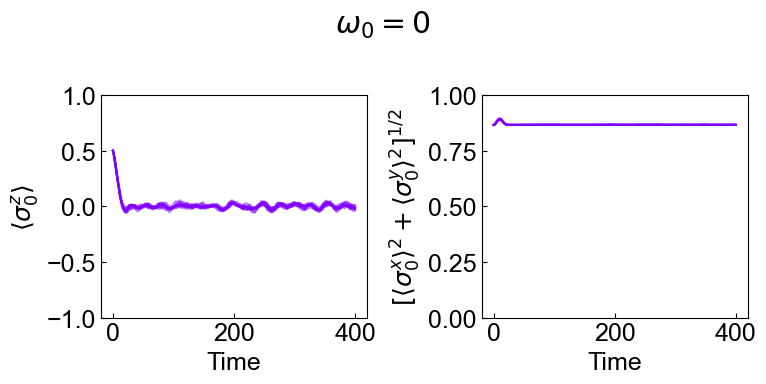

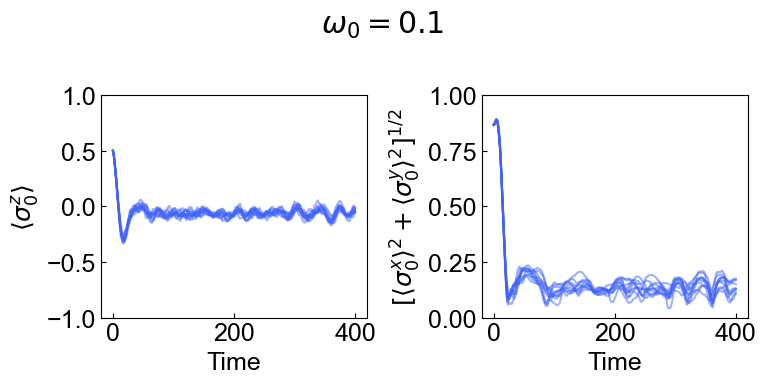

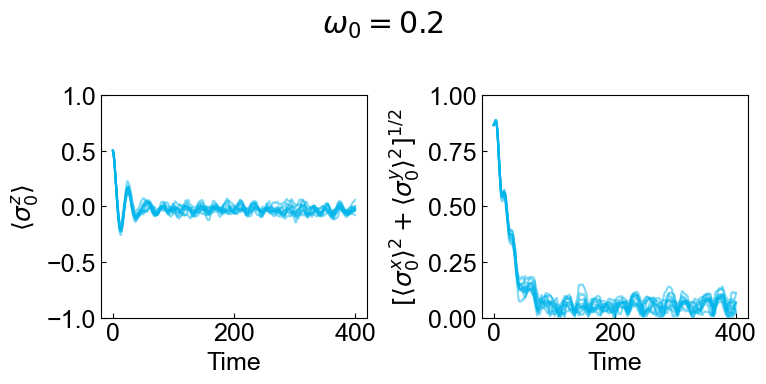

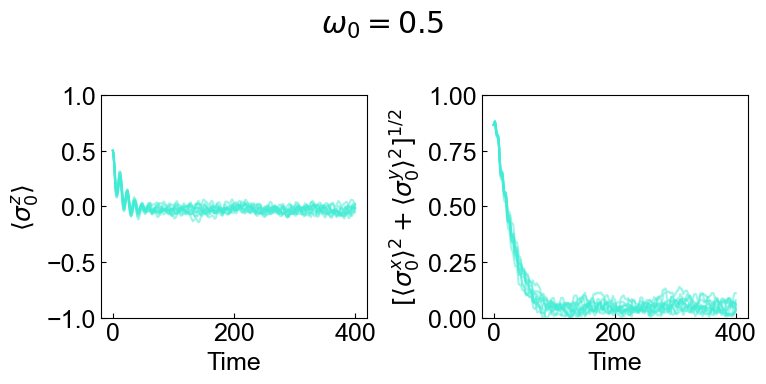

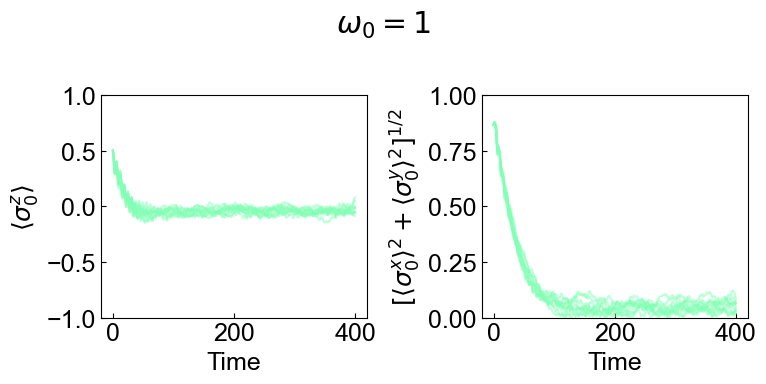

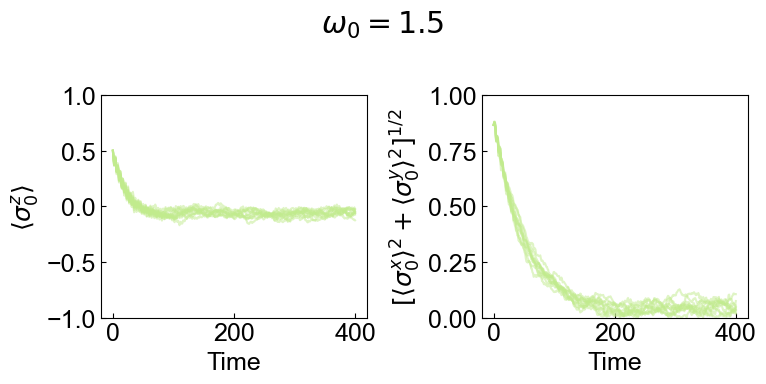

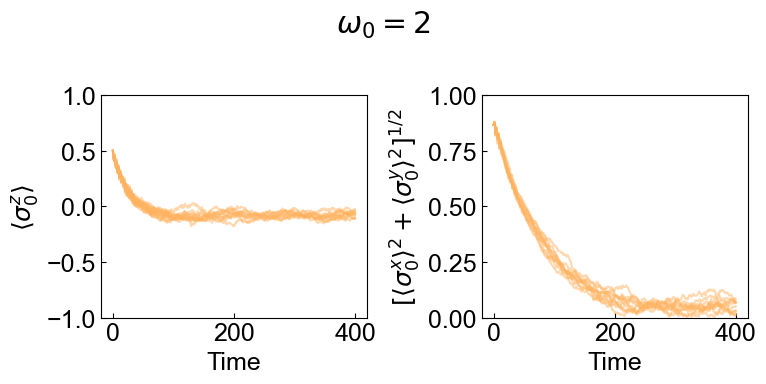

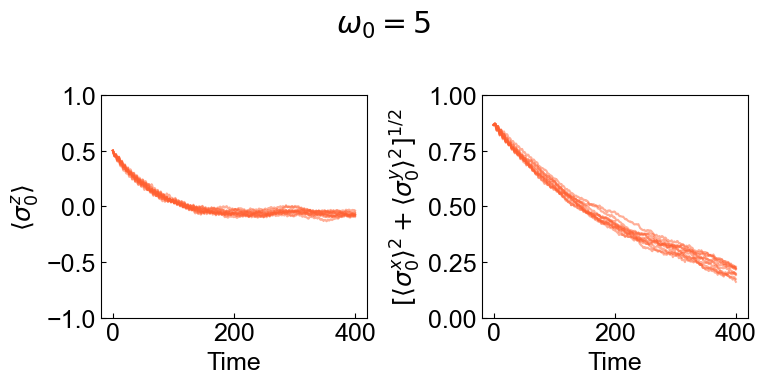

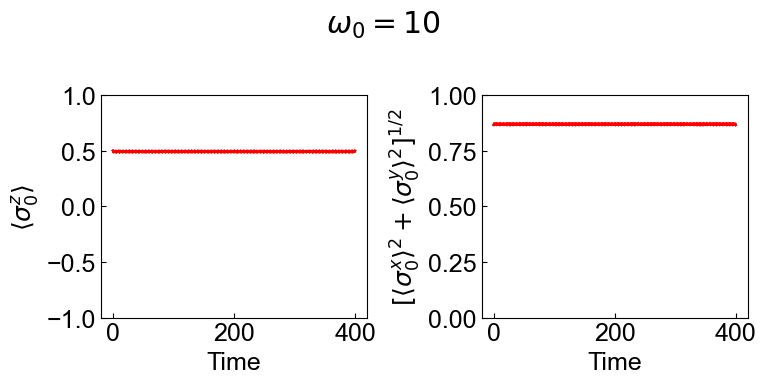

In [23]:
# Plot results
cmap = plt.get_cmap("rainbow")

for idx, w0 in enumerate(w0s):
    fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=100)

    for realization in obs_time_lst[idx]:
        coherence = np.sqrt(realization["X0"] ** 2 + realization["Y0"] ** 2)
        axs[0].plot(times, realization["Z0"], color=cmap(idx / (len(w0s) - 1)), alpha=0.5)
        axs[1].plot(times, coherence, color=cmap(idx / (len(w0s) - 1)), alpha=0.5)

    axs[0].set_ylim(-1, 1)
    axs[0].set_xlabel("Time")
    axs[0].set_ylabel(r"$\langle \sigma_0^z \rangle$")

    axs[1].set_ylim(0, 1)
    axs[1].set_xlabel("Time")
    axs[1].set_ylabel(r"$[\langle \sigma_0^x \rangle^2 + \langle \sigma_0^y \rangle^2]^{1/2}$")

    fig.suptitle(f"$\\omega_0 = {w0s[idx]}$")

    plt.tight_layout()
    plt.show()

In [50]:
# Repeat for many more realizations, computing only final state
L = 12  # Number of bath sites
hx = 1.1  # X field strength
hz = 0.3  # Z field strength
h1 = 0.25  # Z field strength at the first site (site 0)
hL = -0.25  # Z field strength at the last site (site L-1)
g = 0.15  # Coupling strength between the qubit and the bath
w0s = [0, 0.1, 0.2, 0.5, 1, 1.5, 2, 5, 10]  # Qubit frequencies
beta = 0.25  # Inverse temperature
n_realizations = 10 ** 3

# Diagonalize bath Hamiltonian
ha_bath = construct_bath_hamiltonian_analyzer(L, hx, hz, h1, hL)
eigvals_bath, eigvecs_bath = ha_bath.diagonalize(timeit=True)

final_state_lst = []

times = [1e6]

for w0 in tqdm(w0s, desc="Qubit frequencies"):
    ha_total = construct_total_hamiltonian_analyzer(L, hx, hz, h1, hL, g, w0)
    eigvals, eigvecs = ha_total.diagonalize(timeit=True)

    def compute_final_state(i):
        bath_state = StateGenerator().create_thermal_state_pure(beta, eigvals_bath, eigvecs_bath, seed=i)
        obs_time = compute_time_evolution_qubit_pauli(
            ha=ha_total, times=times, qubit_state=qubit_state, bath_state=bath_state, eigvals=eigvals, eigvecs=eigvecs, verbose=False
        )
        return obs_time

    curr_final_state_lst = Parallel(n_jobs=4, verbose=10)(
        delayed(compute_final_state)(i) for i in range(n_realizations)
    )

    final_state_lst.append(curr_final_state_lst)

Hermiticity check passed!
Symmetry checks passed!
Diagonalization took 26.2531 seconds.


Qubit frequencies:   0%|          | 0/9 [00:00<?, ?it/s]

Hermiticity check passed!
Diagonalization took 168.0101 seconds.


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:   41.8s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   46.8s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:   56.5s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:  1.0min
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:  1.2min
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  1.4min
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:  1.6min
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:  1.7min
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:  2.0min
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:  2.3min
[Parallel(n_jobs=4)]: Done 105 tasks      | elapsed:  2.5min
[Parallel(n_jobs=4)]: Done 120 tasks      | elapsed:  2.8min
[Parallel(n_jobs=4)]: Done 137 tasks      | elapsed:  3.1min
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:  3.4min
[Parallel(n_jobs=4)]: Done 173 tasks      | elapsed:  3.7min
[Parallel(

Hermiticity check passed!
Diagonalization took 128.4974 seconds.


...

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    8.6s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   12.7s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:   21.3s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   26.2s
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:   39.7s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   48.1s
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:   59.9s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:  1.1min
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:  1.4min
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:  1.6min
[Parallel(n_jobs=4)]: Done 105 tasks      | elapsed:  1.8min
[Parallel(n_jobs=4)]: Done 120 tasks      | elapsed:  2.1min
[Parallel(n_jobs=4)]: Done 137 tasks      | elapsed:  2.4min
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:  2.7min
[Parallel(n_jobs=4)]: Done 173 tasks      | elapsed:  3.1min
[Parallel(

Hermiticity check passed!
Diagonalization took 132.2938 seconds.


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    8.6s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   12.4s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:   19.6s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   23.6s
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:   33.5s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   40.5s
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:   51.1s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:   58.7s
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:  1.2min
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:  1.4min
[Parallel(n_jobs=4)]: Done 105 tasks      | elapsed:  1.6min
[Parallel(n_jobs=4)]: Done 120 tasks      | elapsed:  1.8min
[Parallel(n_jobs=4)]: Done 137 tasks      | elapsed:  2.1min
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:  2.3min
[Parallel(n_jobs=4)]: Done 173 tasks      | elapsed:  2.6min
[Parallel(

Hermiticity check passed!
Diagonalization took 129.9722 seconds.


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    8.0s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   11.5s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:   18.5s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   22.4s
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:   32.3s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   39.6s
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:   50.3s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:   57.8s
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:  1.2min
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:  1.3min
[Parallel(n_jobs=4)]: Done 105 tasks      | elapsed:  1.6min
[Parallel(n_jobs=4)]: Done 120 tasks      | elapsed:  1.8min
[Parallel(n_jobs=4)]: Done 137 tasks      | elapsed:  2.0min
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:  2.3min
[Parallel(n_jobs=4)]: Done 173 tasks      | elapsed:  2.5min
[Parallel(

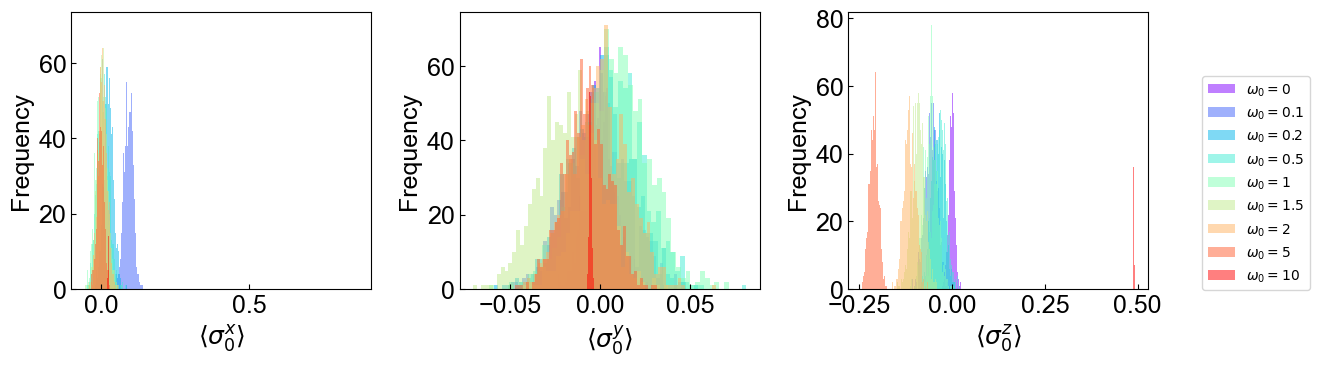

In [61]:
# Plot final state distributions for all qubit frequencies (X, Y, Z projections)
cmap = plt.get_cmap("rainbow")
fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=100)

handles = []
labels = []
for idx, w0 in enumerate(w0s):
    final_states = final_state_lst[idx]
    Xs = np.array([fs["X0"][0] for fs in final_states])
    Ys = np.array([fs["Y0"][0] for fs in final_states])
    Zs = np.array([fs["Z0"][0] for fs in final_states])
    color = cmap(idx / (len(w0s) - 1))
    h1 = axs[0].hist(Xs, bins=50, alpha=0.5, color=color, label=f"$\\omega_0={w0}$")
    h2 = axs[1].hist(Ys, bins=50, alpha=0.5, color=color, label=f"$\\omega_0={w0}$")
    h3 = axs[2].hist(Zs, bins=50, alpha=0.5, color=color, label=f"$\\omega_0={w0}$")
    handles.append(h1[2][0])
    labels.append(f"$\\omega_0={w0}$")

axs[0].set_xlabel(r"$\langle \sigma_0^x \rangle$")
axs[1].set_xlabel(r"$\langle \sigma_0^y \rangle$")
axs[2].set_xlabel(r"$\langle \sigma_0^z \rangle$")

for ax in axs:
    ax.set_ylabel("Frequency")

fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=10)
plt.tight_layout()
plt.show()

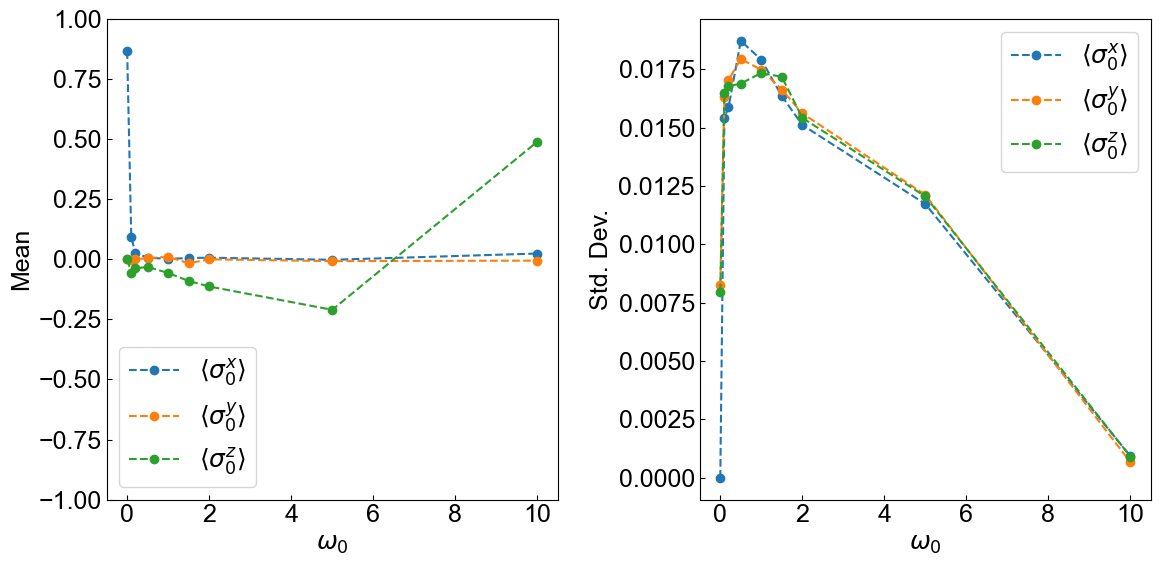

In [64]:
# Plot mean and std. dev. of the histograms as a function of qubit frequency
mean_X = [np.mean([fs["X0"][0] for fs in final_states]) for final_states in final_state_lst]
std_X = [np.std([fs["X0"][0] for fs in final_states]) for final_states in final_state_lst]
mean_Y = [np.mean([fs["Y0"][0] for fs in final_states]) for final_states in final_state_lst]
std_Y = [np.std([fs["Y0"][0] for fs in final_states]) for final_states in final_state_lst]
mean_Z = [np.mean([fs["Z0"][0] for fs in final_states]) for final_states in final_state_lst]
std_Z = [np.std([fs["Z0"][0] for fs in final_states]) for final_states in final_state_lst]

fig, axs = plt.subplots(1, 2, figsize=(12, 6), dpi=100)

# Left pane: Mean vs. w0
axs[0].plot(w0s, mean_X, "o--", color="C0", label=r"$\langle \sigma_0^x \rangle$")
axs[0].plot(w0s, mean_Y, "o--", color="C1", label=r"$\langle \sigma_0^y \rangle$")
axs[0].plot(w0s, mean_Z, "o--", color="C2", label=r"$\langle \sigma_0^z \rangle$")
axs[0].set_ylim(-1, 1)
axs[0].set_xlabel(r"$\omega_0$")
axs[0].set_ylabel(r"Mean")
axs[0].legend()

# Right pane: Std. dev. vs. w0
axs[1].plot(w0s, std_X, "o--", color="C0", label=r"$\langle \sigma_0^x \rangle$")
axs[1].plot(w0s, std_Y, "o--", color="C1", label=r"$\langle \sigma_0^y \rangle$")
axs[1].plot(w0s, std_Z, "o--", color="C2", label=r"$\langle \sigma_0^z \rangle$")
axs[1].set_xlabel(r"$\omega_0$")
axs[1].set_ylabel(r"Std. Dev.")
axs[1].legend()

plt.tight_layout()
plt.show()
